In [49]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
from tqdm import tqdm
import math
import glob
import uproot
import torch
from torch import nn, optim
import vector
import numpy as np
import awkward as ak
import itertools
import matplotlib
import matplotlib.pyplot as plt
from hepunits import units
from IPython.display import clear_output
import lightning as L
from lightning.pytorch import loggers as pl_loggers
import torch
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader
import random
vector.register_awkward()

src_path = os.path.abspath('../src/')
print (src_path)
if src_path not in sys.path:
    sys.path.append(src_path)

from datasets import *
from models import *
from callbacks import *
from annealing import *
from constants import X0_VALUES
from distributions import *
from propagation import *
from torch.nn.utils import spectral_norm
print (f"Running on GPU : {torch.cuda.is_available()}")
accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
print (f"Accelerator : {accelerator}")
torch.set_float32_matmul_precision('medium')
import random
from PIL import Image, ImageDraw
X0_VALUES

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
C:\Users\Administrator\Desktop\MuonPropagation-Shaivya_shankar2\MuonPropagation-Shaivya_shankar\src
Running on GPU : True
Accelerator : gpu


{'U': 3.166,
 'Pb': 5.612,
 'Fe': 17.57,
 'Al': 88.97,
 'Ca': 104.2,
 'SILICON_DIOXIDE': 122.89999999999999,
 'WATER': 360.79999999999995,
 'AIR': 303900.0}

In [30]:
## Get files #
data_path = '../data/'
material = 'Pb'
files = sorted(glob.glob(os.path.join(data_path,f'*{material}*.root')))
print(f"Found {len(files)} files for material '{material}'.")

# Main args #
args = {
    # Boilerplate arguments #
    'position_vars' : ['pos_x','pos_y','pos_z'],
    'position_unit' : units.cm,
    'momentum_vars' : ['p_x','p_y','p_z'],
    'momentum_unit' : units.MeV,
    'initial_energy_var' : 'initial_energy',
    'initial_energy_unit' : units.GeV,
    'dtype' : torch.float32,
    'X0' : X0_VALUES[material]
}

# --- Using GANDataset for the GAN ---
# This is the correct approach. The GANDataset is specifically designed
# to prepare the tensors required for conditional GAN training.

dataset_train = GANDataset(
    files = files[:1],
    **args
)
dataset_valid = GANDataset(
    files = files[-2],
    scaling = dataset_train.scaling,
    **args
)
dataset_test = GANDataset(
    files = files[-1],
    scaling = dataset_train.scaling,
    mask_per_track = True,
    **args
)


batch_size = 10000

# --- DataLoaders for the GAN ---
# This setup remains identical. The loader will provide batches of data
# containing the necessary 'condition' and 'target' keys from the GANDataset.

loader_train = DataLoader(
    dataset = dataset_train,
    batch_size = batch_size,
    shuffle = True,
)
loader_valid = DataLoader(
    dataset = dataset_valid,
    batch_size = 10000,
    shuffle = False,
)
print("\nScaler configuration to be used for GAN training:")
print(dataset_train.scaling)

Found 3 files for material 'Pb'.


Files:   0%|          | 0/1 [00:00<?, ?it/s]

Concatenating arrays
... done
Producing 3D position vector
2000 * var * Vector3D[
    x: float64,
    y: float64,
    z: float64
]
Producing 3D momentum vector
2000 * var * Momentum3D[
    px: float64,
    py: float64,
    pz: float64
]
2000 * var * Momentum3D[
    px: float64,
    py: float64,
    pz: float64
]
Out of 1998000 steps, selecting 1997990 [99.999%]


Files:   0%|          | 0/1 [00:00<?, ?it/s]

Concatenating arrays
... done
Producing 3D position vector
2000 * var * Vector3D[
    x: float64,
    y: float64,
    z: float64
]
Producing 3D momentum vector
2000 * var * Momentum3D[
    px: float64,
    py: float64,
    pz: float64
]
2000 * var * Momentum3D[
    px: float64,
    py: float64,
    pz: float64
]
Out of 1998000 steps, selecting 1997988 [99.999%]


Files:   0%|          | 0/1 [00:00<?, ?it/s]

Concatenating arrays
... done
Producing 3D position vector
2000 * var * Vector3D[
    x: float64,
    y: float64,
    z: float64
]
Producing 3D momentum vector
2000 * var * Momentum3D[
    px: float64,
    py: float64,
    pz: float64
]
2000 * var * Momentum3D[
    px: float64,
    py: float64,
    pz: float64
]
Out of 2000 tracks, selecting 1988 [99.400%]

Scaler configuration to be used for GAN training:

Preprocessing steps
Step applied to ['condition']
	P   : <class 'scaling.logscaler'>
	X0  : <class 'scaling.logscaler'>
  - condition : ('P', 'X0')
Step applied to ['condition']
	P   : <class 'scaling.SklearnScaler'>
	X0  : <class 'scaling.SklearnScaler'>
  - condition : ('P', 'X0')
Step applied to ['input', 'target']
	-dP     : <class 'scaling.logscaler'>
	dtheta  : <class 'scaling.logscaler'>
	dr      : <class 'scaling.logscaler'>
  - input  : ('-dP', 'dtheta', 'dr')
  - target : ('-dP', 'dtheta', 'dr')
Step applied to ['input', 'target']
	-dP     : <class 'scaling.SklearnScaler'>

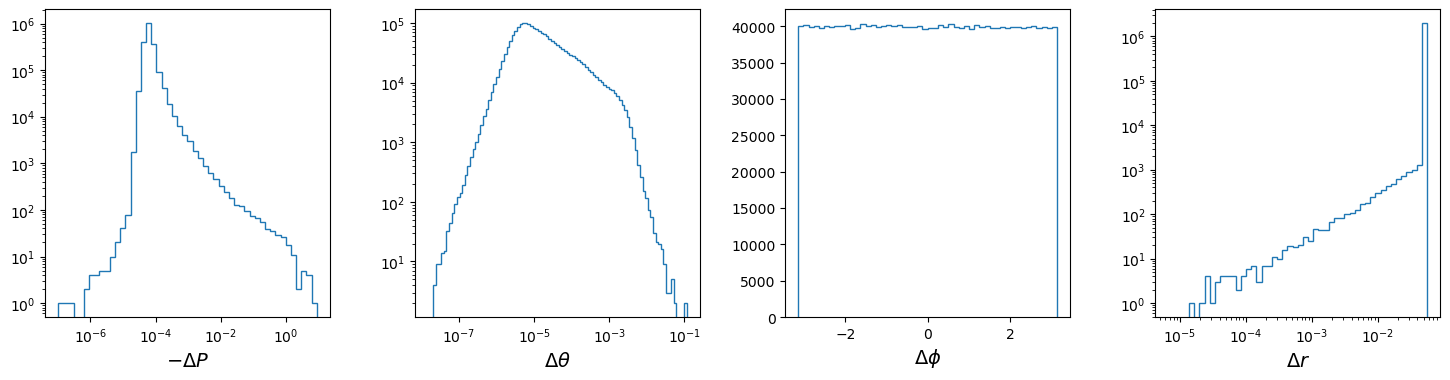

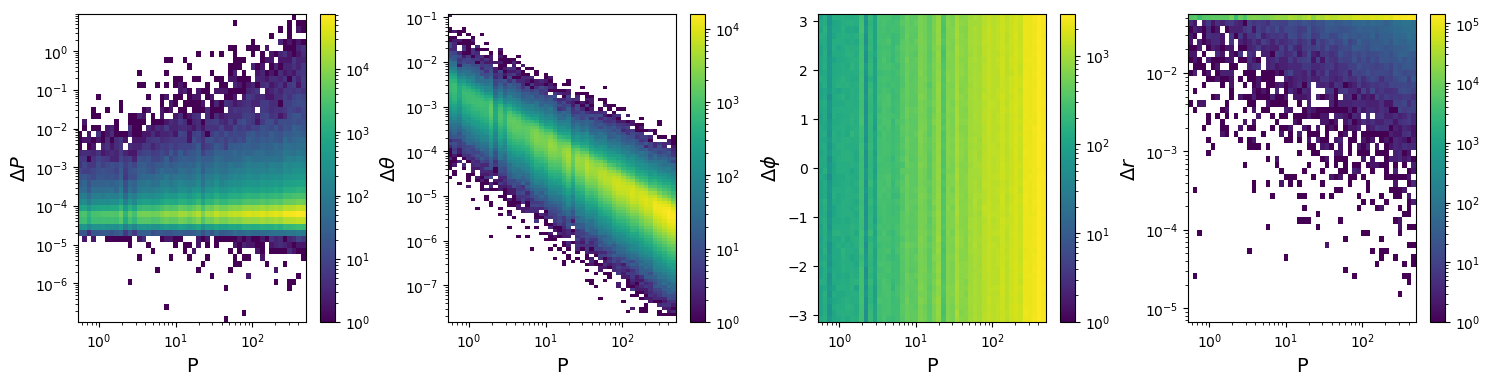

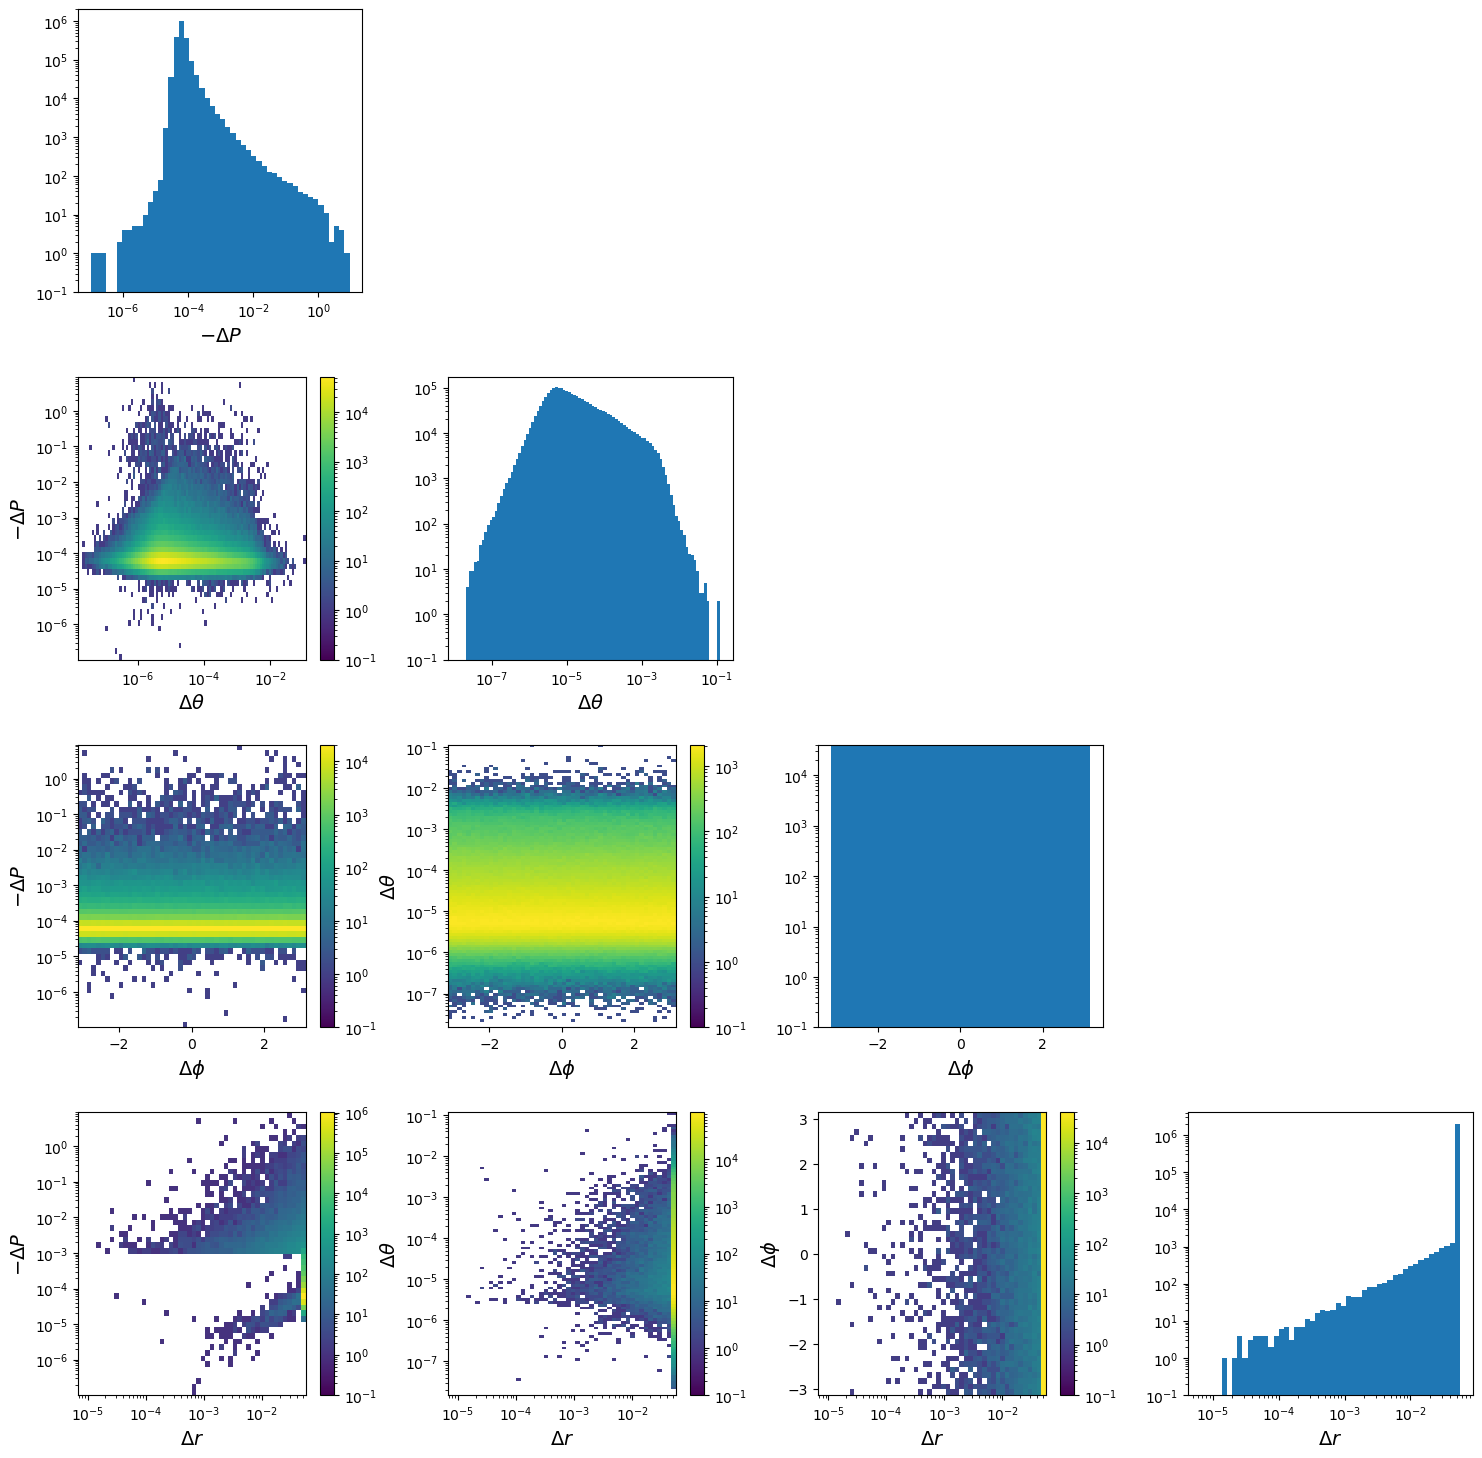

In [50]:
figs = dataset_train.plot_variations(show=True)

preprocessed


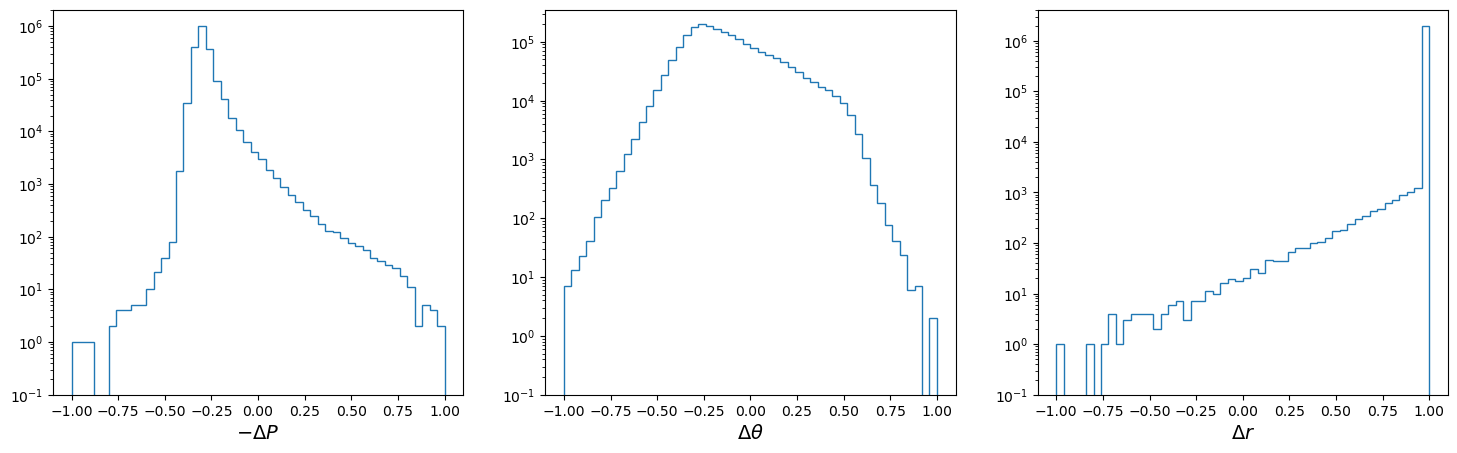

original


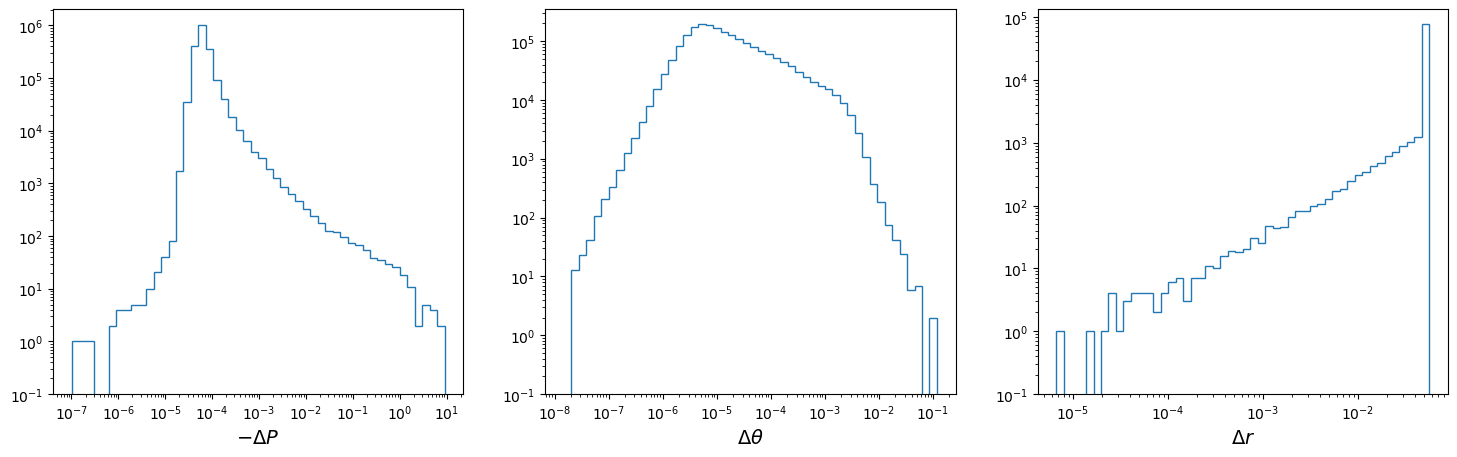

In [4]:
print ('preprocessed')
fig = dataset_train.plot_variable_1D('target',preprocessed=True,log=True)
print ('original')
fig = dataset_train.plot_variable_1D('target',preprocessed=False,log=True)

preprocessed


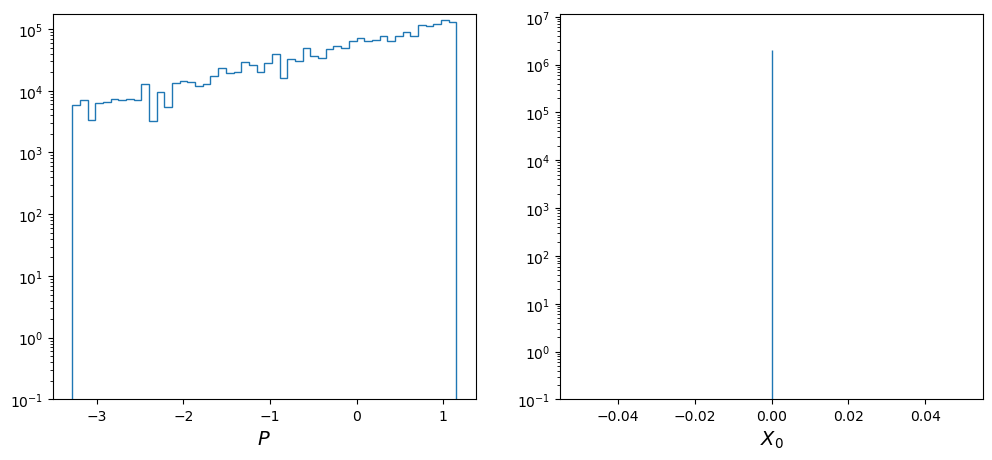

original


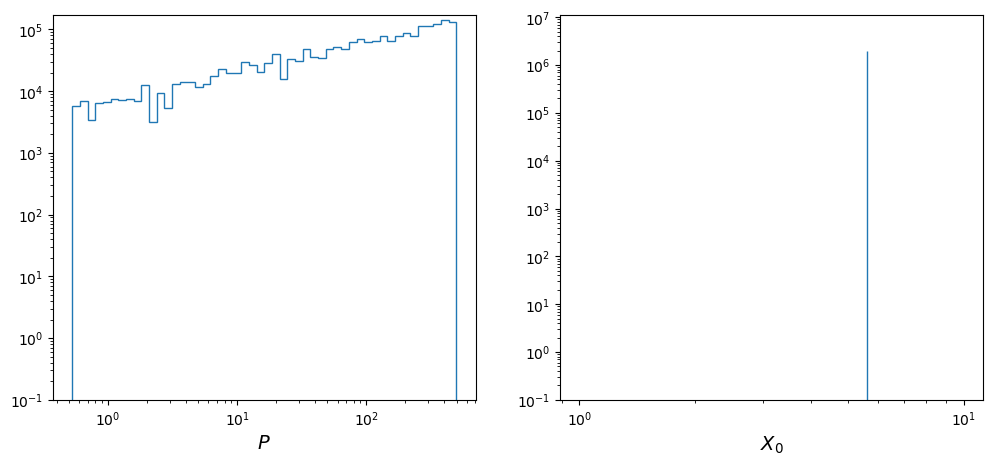

In [5]:
print ('preprocessed')
fig = dataset_train.plot_variable_1D('condition',preprocessed=True,log=True)
print ('original')
fig = dataset_train.plot_variable_1D('condition',preprocessed=False,log=True)

preprocessed


C:\Users\Administrator\Desktop\MuonPropagation-Shaivya_shankar (1)\MuonPropagation-Shaivya_shankar\src\datasets.py:1028: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  h = axs[i,j].hist2d(


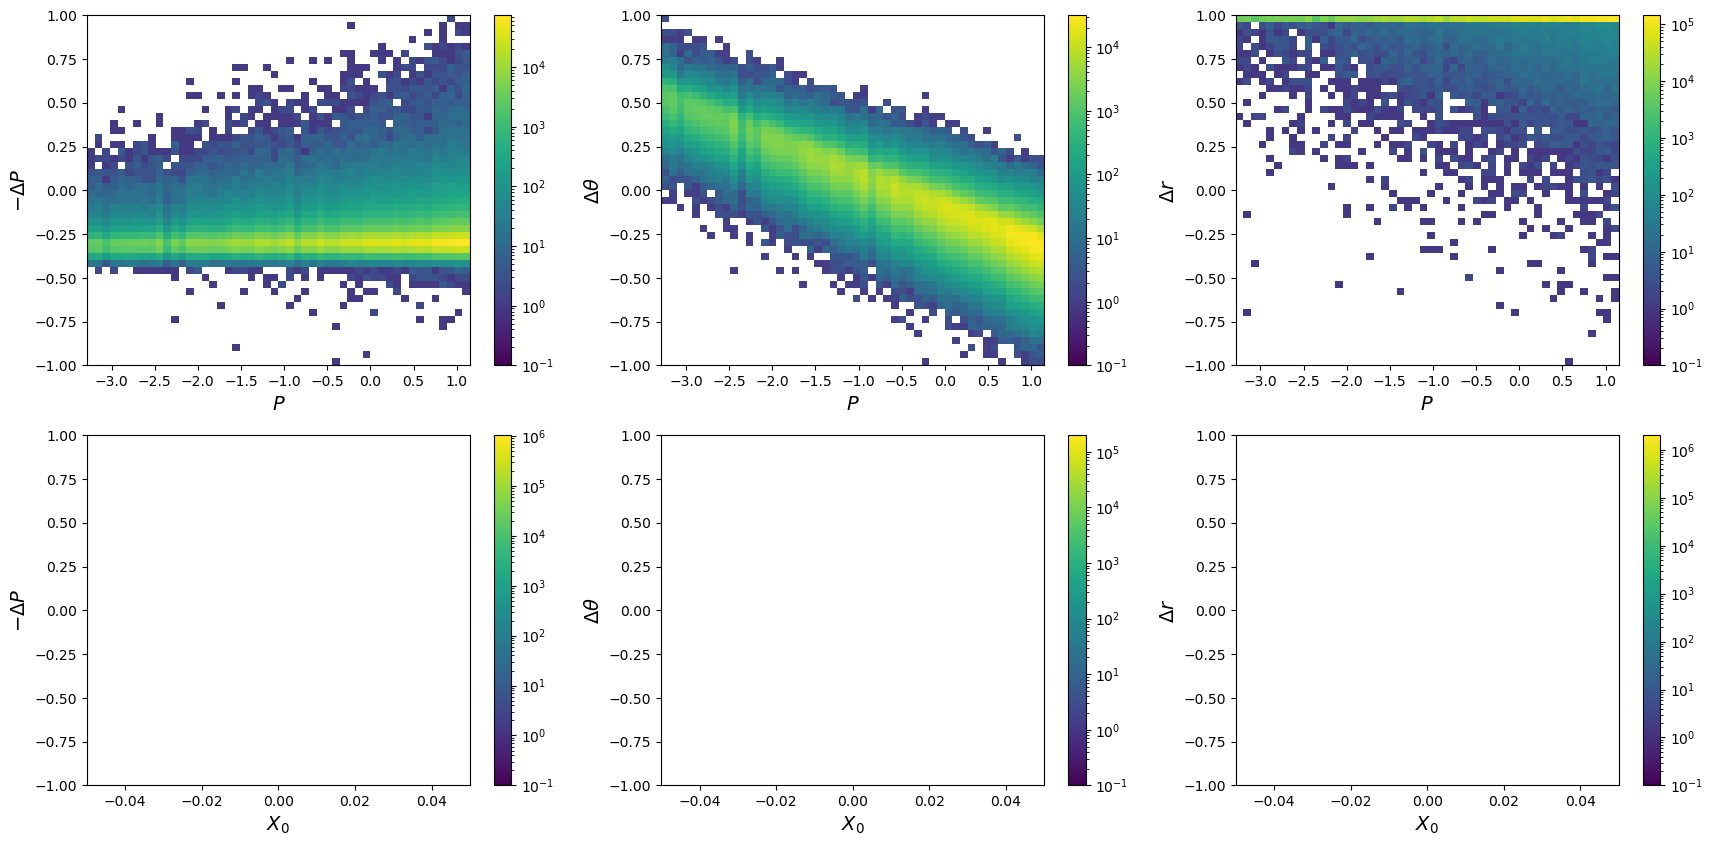

original


C:\Users\Administrator\Desktop\MuonPropagation-Shaivya_shankar (1)\MuonPropagation-Shaivya_shankar\src\datasets.py:1028: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  h = axs[i,j].hist2d(


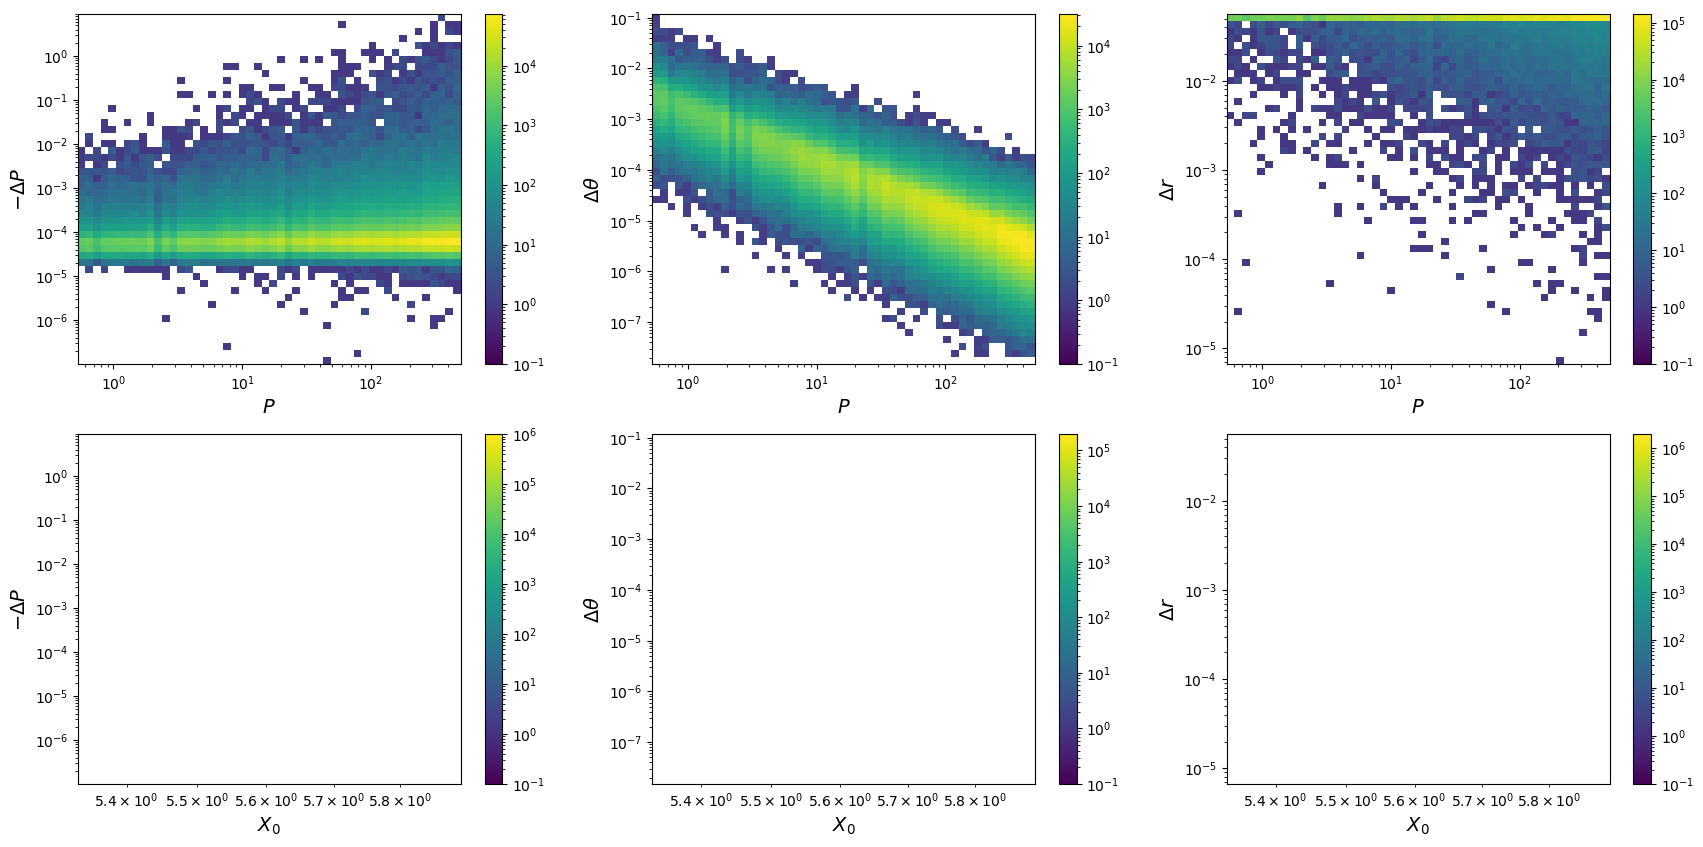

In [8]:
print ('preprocessed')
fig = dataset_train.plot_variable_2D(name_x='condition',name_y='target',preprocessed=True,log=True)
print ('original')
fig = dataset_train.plot_variable_2D(name_x='condition',name_y='target',preprocessed=False,log=True)

preprocessed


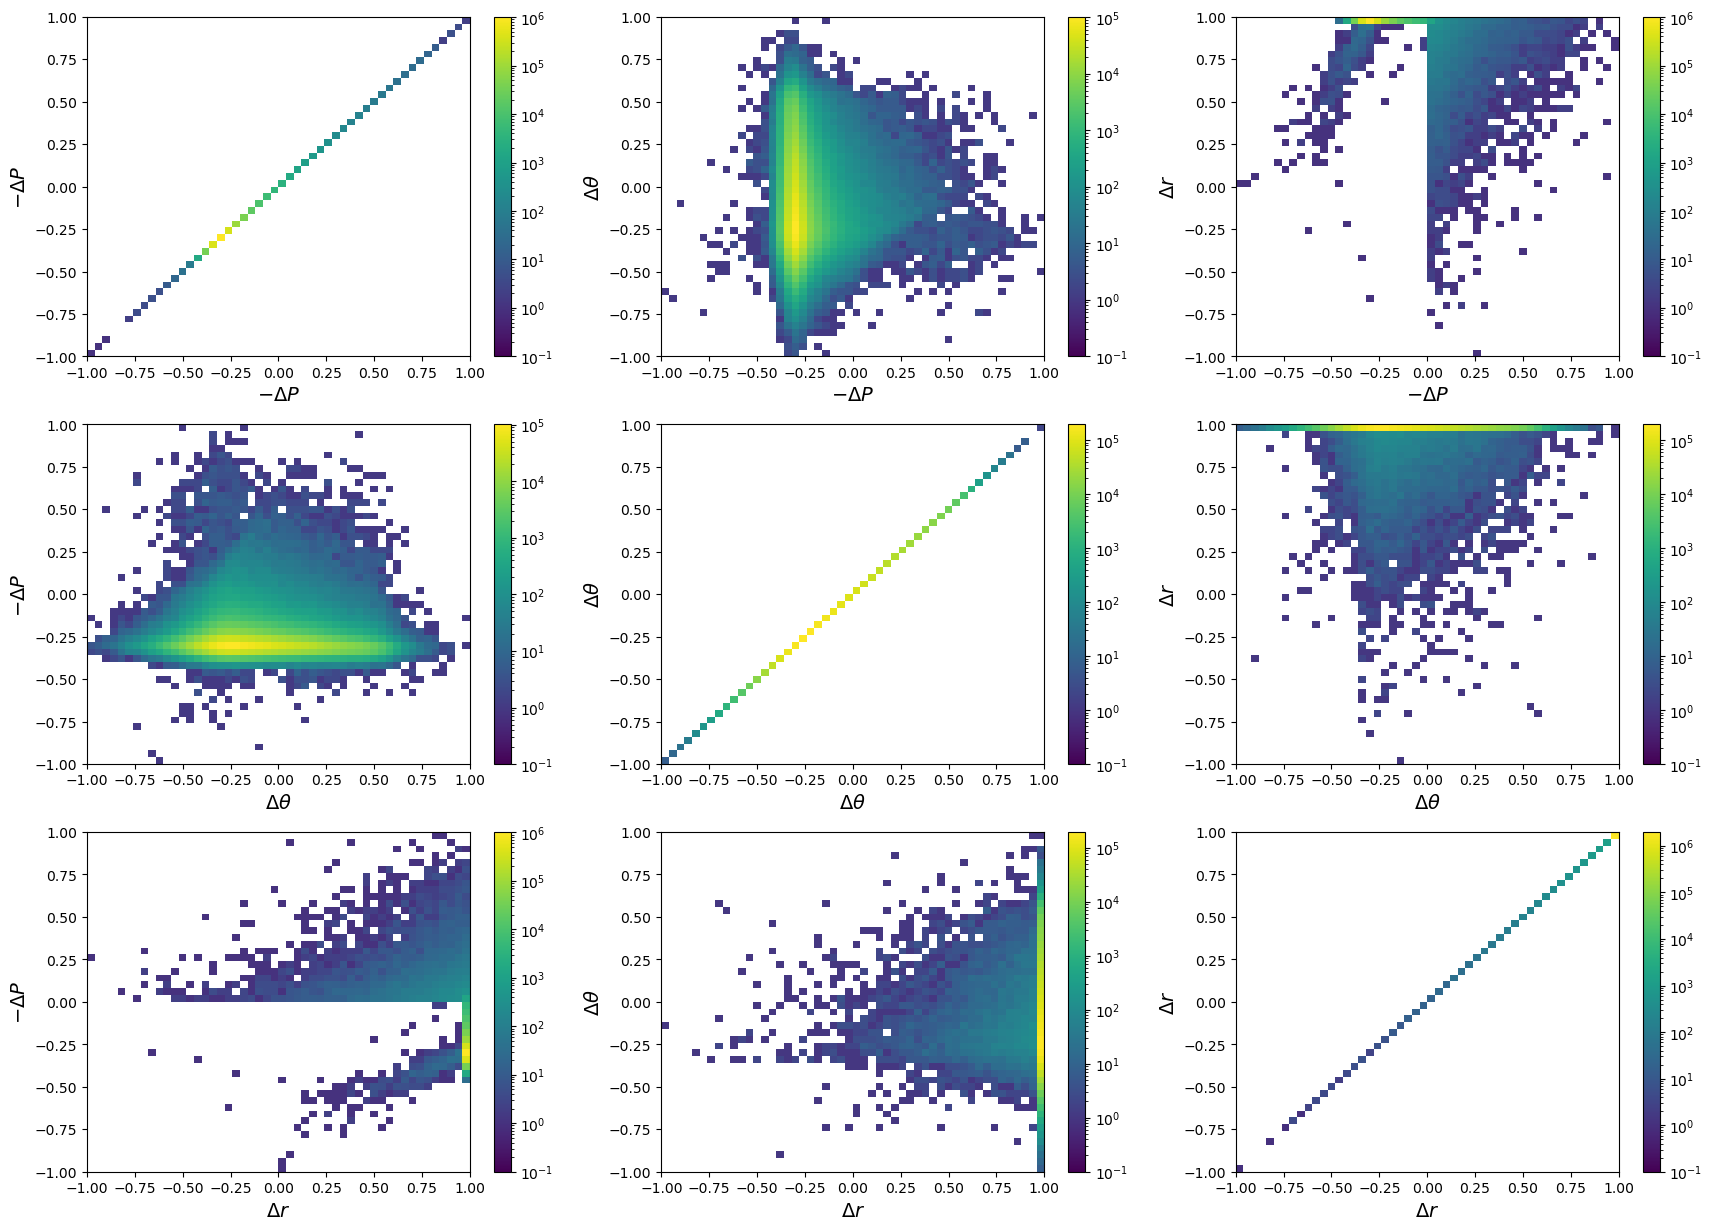

original


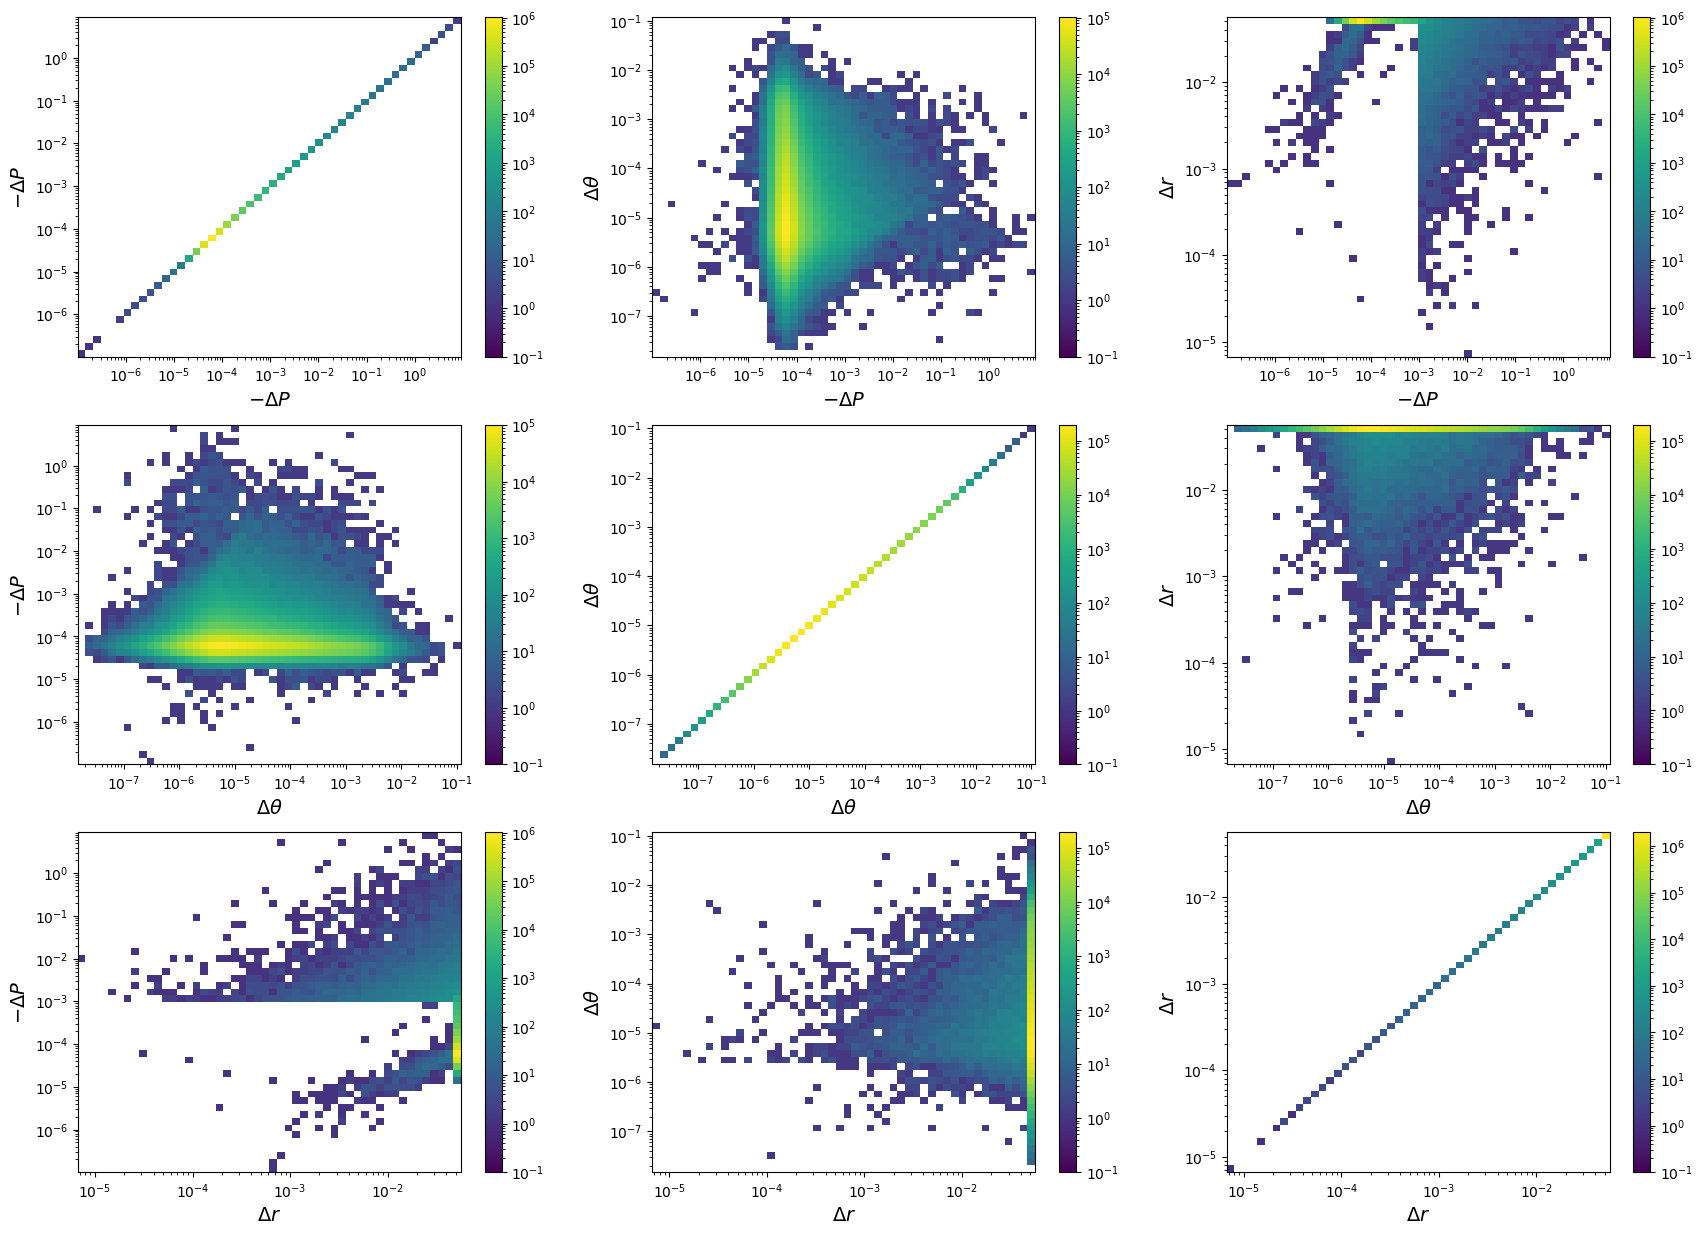

In [9]:
print ('preprocessed')
fig = dataset_train.plot_variable_2D(name_x='input',name_y='target',preprocessed=True,log=True)
print ('original')
fig = dataset_train.plot_variable_2D(name_x='input',name_y='target',preprocessed=False,log=True)

In [51]:
class MLP(nn.Module):
    def __init__(self, dim_in, dim_out, neurons, hidden_activation, 
                 output_activation=None, use_batchnorm=False, use_layernorm=False, 
                 use_spectralnorm=False, use_dropout=False, dropout_prob=0.0):
        super().__init__()
        
        if use_batchnorm and use_layernorm:
            raise ValueError("Cannot use both BatchNorm and LayerNorm at the same time.")
            
        layers = []
        current_dim = dim_in
        
        for i, n in enumerate(neurons):
            # Create the linear layer
            linear_layer = nn.Linear(current_dim, n)
            
            # --- MODIFICATION: Conditionally apply spectral norm to the linear layer ---
            if use_spectralnorm:
                layers.append(spectral_norm(linear_layer))
            else:
                layers.append(linear_layer)
            
            # Add other normalization layers if specified
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(n))
            elif use_layernorm:
                layers.append(nn.LayerNorm(n))
                
            layers.append(hidden_activation() if callable(hidden_activation) else hidden_activation)
            
            if use_dropout and dropout_prob > 0 and i < len(neurons) - 1:
                layers.append(nn.Dropout(dropout_prob))
                
            current_dim = n
            
        # Final output layer (spectral norm is also often applied here)
        output_layer = nn.Linear(current_dim, dim_out)
        if use_spectralnorm:
            layers.append(spectral_norm(output_layer))
        else:
            layers.append(output_layer)
        
        if output_activation:
            layers.append(output_activation if isinstance(output_activation, nn.Module) else output_activation())
            
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


class Generator(nn.Module):
    def __init__(self, cond_dim, noise_dim, hidden_dims, output_dim=3):
        super().__init__()
        self.noise_dim = noise_dim
        
        self.network = MLP(
            dim_in=cond_dim + noise_dim,
            dim_out=output_dim,
            neurons=hidden_dims,
            hidden_activation=nn.GELU,
            output_activation=nn.Tanh(),          
            use_batchnorm=True, 
            use_layernorm=False,
            use_spectralnorm=False
        )

    def forward(self, condition, noise):
        combined_input = torch.cat([condition, noise], dim=1)
        return self.network(combined_input)


class Discriminator(nn.Module):
    def __init__(self, data_dim, cond_dim, hidden_dims):
        super().__init__()
        self.network = MLP(
            dim_in=data_dim + cond_dim,
            dim_out=1,
            neurons=hidden_dims,
            hidden_activation=nn.GELU,
            output_activation=nn.Sigmoid(),
            use_batchnorm=False,     
            use_layernorm=False,      
            use_spectralnorm=False   
        )

    def forward(self, data_sample, condition):
        combined_input = torch.cat([data_sample, condition], dim=1)
        return self.network(combined_input)

In [52]:
# --- Optimal Hyperparameters from Optuna ---

best_lr = 3e-05
best_beta1 =0.5682096494749166
best_d_layers = 2
best_d_neurons = 128

best_g_layers = 2
best_g_neurons = 128

# --- Training Configuration ---
epochs      = 400
beta2       = 0.999
noise_dim   = 3 # Using a more standard noise dimension than 3


g_hidden_dims = [best_g_neurons] * best_g_layers
d_hidden_dims = [best_d_neurons] * best_d_layers


condition_dim = dataset_train.condition_dim
target_dim    = dataset_train.target_dim


# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

generator = Generator(
    cond_dim=condition_dim,
    noise_dim=noise_dim,
    hidden_dims=g_hidden_dims,
    output_dim=target_dim
).to(device)

discriminator = Discriminator(
    data_dim=target_dim,
    cond_dim=condition_dim,
    hidden_dims=d_hidden_dims
).to(device)

# --- Optimizers with optimal lr and beta1 ---
g_optimizer  = torch.optim.Adam(generator.parameters(), lr=best_lr, betas=(best_beta1, beta2))
d_optimizer= torch.optim.Adam(discriminator.parameters(), lr=best_lr, betas=(best_beta1, beta2))
criterion = nn.BCELoss()

print("Models and optimizers are ready for final training.")
print(f"Generator architecture: {best_g_layers} layers, {best_g_neurons} neurons each.")
print(f"Discriminator architecture: {best_d_layers} layers, {best_d_neurons} neurons each.")


Using device: cuda
Models and optimizers are ready for final training.
Generator architecture: 2 layers, 128 neurons each.
Discriminator architecture: 2 layers, 128 neurons each.


In [53]:
g_loss_hist, d_loss_hist = [], []
print('\n─── Starting Simplified GAN Training ───')
for epoch in range(1, epochs + 1):
    generator.train()
    discriminator.train()

    epoch_g_losses, epoch_d_losses = [], []

    for batch in tqdm(loader_train, desc=f'Epoch {epoch}/{epochs}', leave=False):
        conditions = batch['condition'].to(device)
        real_targets = batch['target'].to(device)
        batch_size = real_targets.size(0)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # ---------------------
        #  Train Discriminator
        # ---------------------
        d_optimizer.zero_grad()
        real_pred = discriminator(real_targets, conditions)
        d_real_loss = criterion(real_pred, real_labels)
        noise = torch.randn(batch_size, noise_dim, device=device)
        fake_targets = generator(conditions, noise).detach()
        fake_pred = discriminator(fake_targets, conditions)
        d_fake_loss = criterion(fake_pred, fake_labels)
        d_loss = 0.5 * (d_real_loss + d_fake_loss)
        d_loss.backward()
        d_optimizer.step()

        # -----------------
        #  Train Generator
        # -----------------
        g_optimizer.zero_grad()
        noise = torch.randn(batch_size, noise_dim, device=device)
        fake_targets = generator(conditions, noise)
        fake_pred = discriminator(fake_targets, conditions)
        g_loss = criterion(fake_pred, real_labels)
        g_loss.backward()
        g_optimizer.step()
        
        epoch_g_losses.append(g_loss.item())
        epoch_d_losses.append(d_loss.item())

    # --- Store epoch average losses ---
    avg_g_loss = np.mean(epoch_g_losses)
    avg_d_loss = np.mean(epoch_d_losses)
    g_loss_hist.append(avg_g_loss)
    d_loss_hist.append(avg_d_loss)

    print(f"Epoch {epoch:2d}/{epochs} | G_loss {avg_g_loss:.4f} | D_loss {avg_d_loss:.4f}")

  
    if (epoch % 100 == 0 and epoch > 0) or epoch == epochs:
        print(f"\n--- Generating and saving plots for epoch {epoch} ---")
        generator.eval() # Ensure generator is in evaluation mode


        
        output_dir = f"../notebooks/Gan_with_Batch_normalization_in_generator/{material}/epoch_{epoch}"
        os.makedirs(output_dir, exist_ok=True)
        print(f"  Saving plots for {material} to: {output_dir}")

        # Prepare conditions for plotting
        Ps = torch.logspace(math.log10(0.5), math.log10(500), 51)
        X0s = torch.tensor([X0_VALUES[material]])

        # Create a sampling callback instance to generate plots
        sampling_callback = GANSamplingCallback(
            values=[Ps, X0s], # Pass both tensors
            scaling=dataset_test.scaling,
            plotting_config=dataset_test.plotting_config
        )
        
        # Generate the dictionary of figures without showing them
        figs_sampling = sampling_callback.make_plots(generator, show=False)

        # Save each figure to the specified directory
        for figname, fig in figs_sampling.items():
            save_path = os.path.join(output_dir, f"{figname}.png")
            fig.savefig(save_path, bbox_inches='tight', dpi=150)
        
        plt.close('all') # Close all figures to free up memory
        print("--- Finished saving plots. Resuming training... ---")   

print("\n--- Training Complete ---")


─── Starting Simplified GAN Training ───


Epoch 1/400:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch  1/400 | G_loss 0.6654 | D_loss 0.6726


Epoch 2/400:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch  2/400 | G_loss 0.6515 | D_loss 0.6660


...

Epoch 398/400 | G_loss 0.6923 | D_loss 0.6932


Epoch 399/400:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 399/400 | G_loss 0.6931 | D_loss 0.6932


Epoch 400/400:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 400/400 | G_loss 0.6937 | D_loss 0.6932

--- Generating and saving plots for epoch 400 ---
  Saving plots for Pb to: ../notebooks/Gan_with_Batch_normalization_in_generator/Pb/epoch_400
--- Finished saving plots. Resuming training... ---

--- Training Complete ---


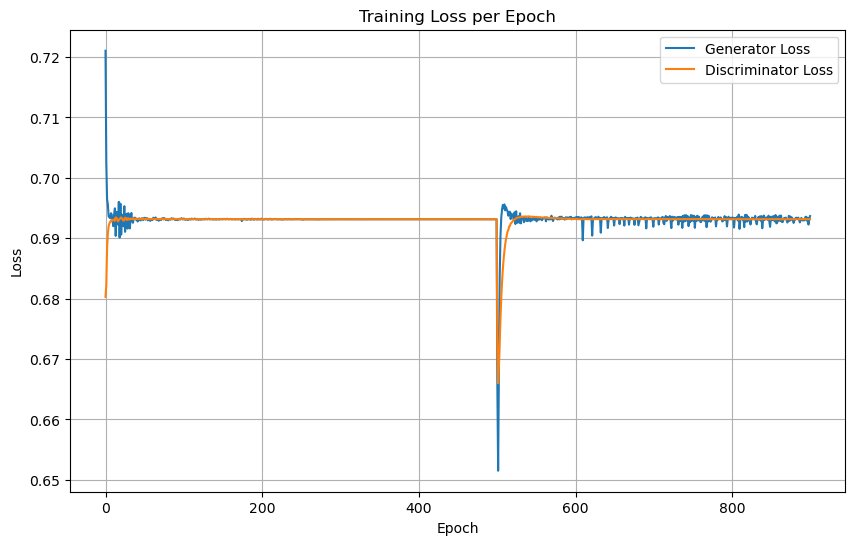

In [54]:
plt.figure(figsize=(10, 6))

# Plot the generator and discriminator loss histories
plt.plot(g_loss_hist, label='Generator Loss')
plt.plot(d_loss_hist, label='Discriminator Loss')

# Add a title and labels
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

In [19]:
torch.save(generator.state_dict(), 'generator_model.pth')

In [36]:
torch.save(discriminator.state_dict(), 'discriminator_model.pth')

In [15]:
generator.to(device).eval()

Generator(
  (network): MLP(
    (network): Sequential(
      (0): Linear(in_features=5, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): GELU(approximate='none')
      (4): Linear(in_features=128, out_features=3, bias=True)
      (5): Tanh()
    )
  )
)

In [18]:

print("\n--- Generating Generator Sampling Plots ---")
generator.noise_dim = noise_dim



--- Generating Generator Sampling Plots ---


In [40]:
# This class handles the particle propagation simulations using the generator.
class GANPropagator(VAEPropagator):
    def __init__(self, model, scaling=None, noise_dim=32, **kwargs):
        # The 'model' for this propagator is the GAN's generator
        super().__init__(model=model, scaling=scaling, **kwargs)
        self.noise_dim = noise_dim
        self.dist_phi = torch.distributions.Uniform(low=-math.pi, high=math.pi)

    def apply_step(self, step, P_in):
        device = next(self.model.parameters()).device
        
        P = torch.norm(P_in, p=2., dim=1).unsqueeze(-1)
        X0 = torch.ones_like(P) * self.X0
        condition = torch.cat((P, X0), dim=-1)
        
        if self.scaling is not None:
            # **FIX:** Move condition to CPU for scaling, then back to GPU for the model
            condition_cpu = condition.cpu()
            condition_scaled = self.scaling.transform(
                name='condition', x=condition_cpu, features=['P', 'X0']
            )
            condition = condition_scaled.to(device)
        else:
            condition = condition.to(device)

        with torch.no_grad():
            noise = torch.randn(condition.size(0), self.noise_dim, device=device)
            DP = self.model(condition, noise).cpu().detach()

        if self.scaling is not None:
            DP = self.scaling.inverse(
                name='target', x=DP, features=['-dP', 'dtheta', 'dr']
            )

        dP, dtheta, dr = torch.split(DP, 1, dim=-1)
        dphi = self.dist_phi.sample((P_in.shape[0],))
        
        return dP.squeeze(-1), dtheta.squeeze(-1), dphi, dr.squeeze(-1)

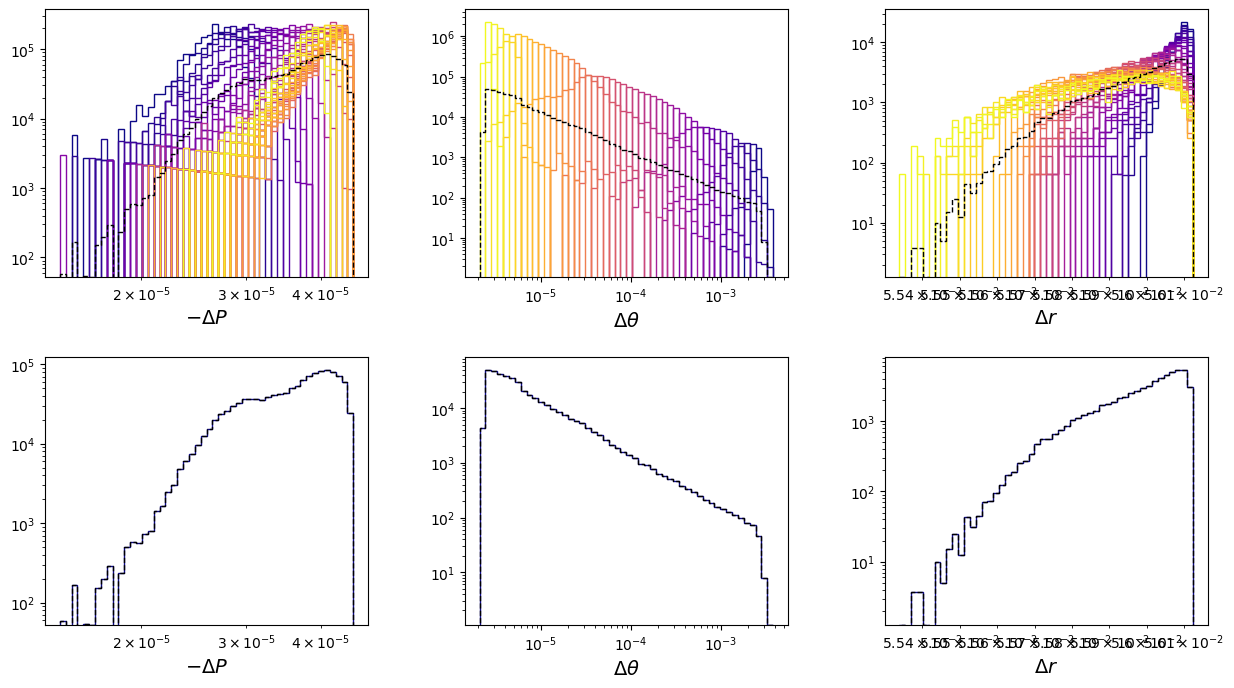

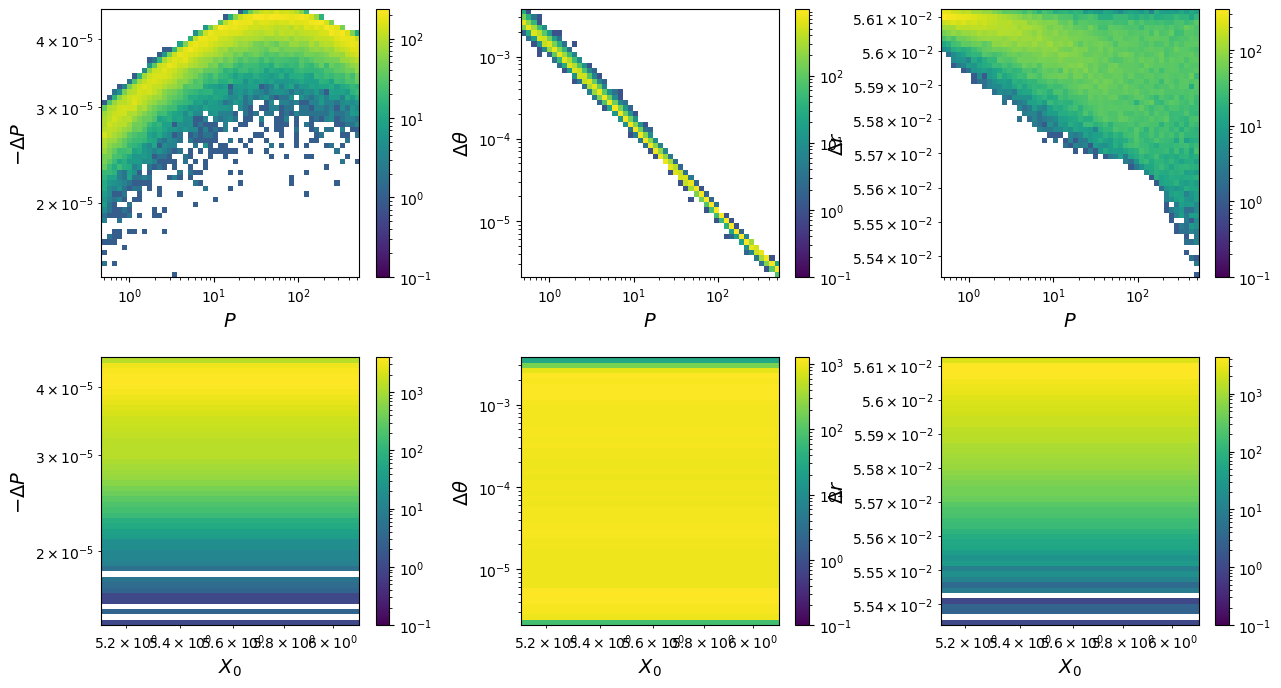

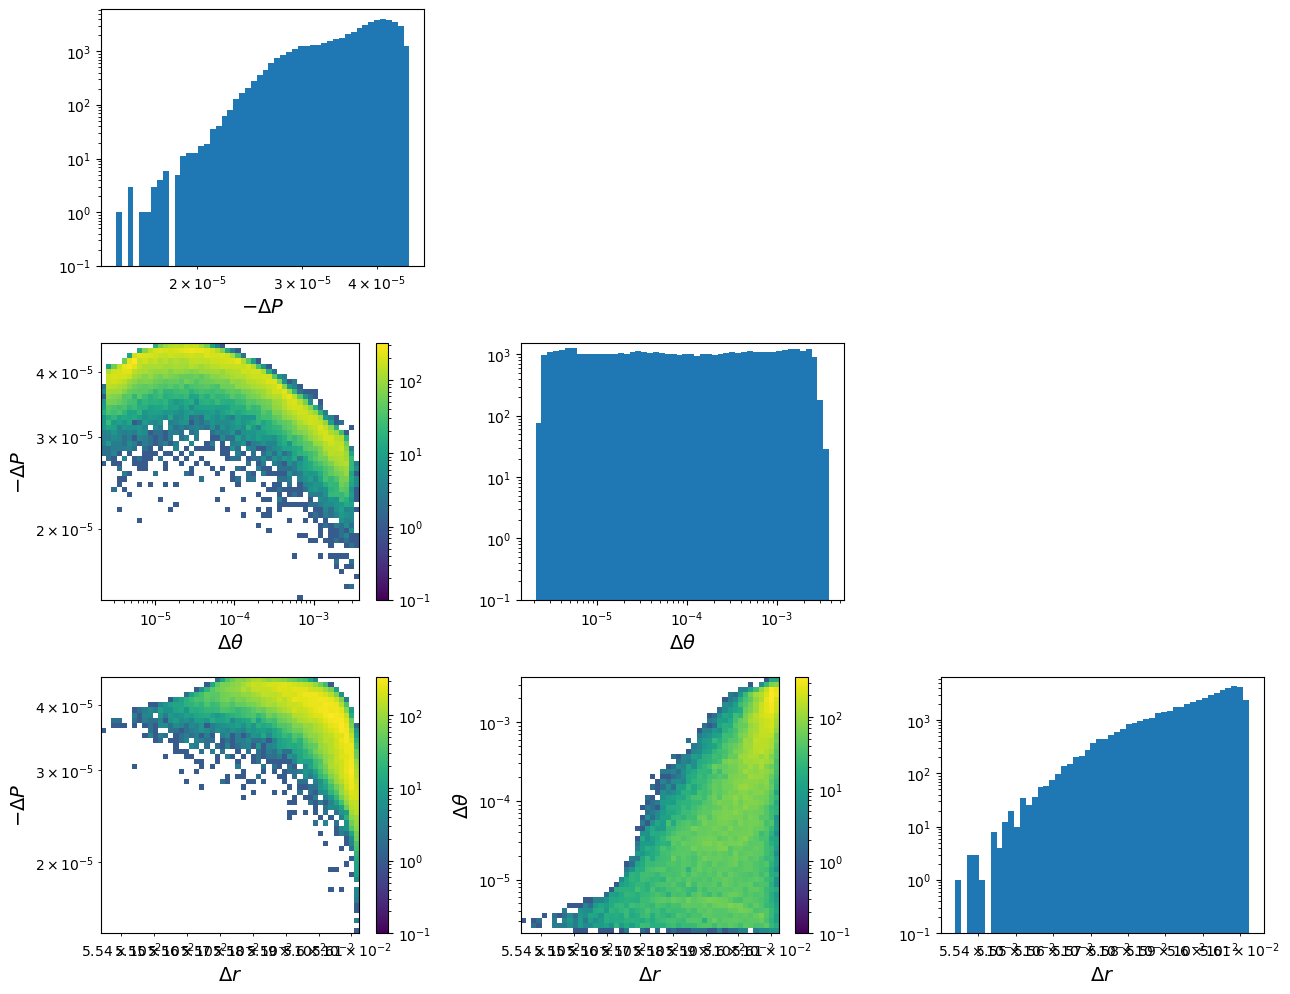

In [47]:
Ps = torch.logspace(math.log10(0.5),math.log10(500),51)
X0s = torch.tensor([X0_VALUES[material]])
 
sampling_callback = GANSamplingCallback(
    values=[Ps, X0s], # Pass both tensors
    scaling=dataset_train.scaling,
    plotting_config=dataset_test.plotting_config
)
figs_sampling = sampling_callback.make_plots(generator, show=True)

# Propagation

In [41]:
# --- Create and run the Propagation plots ---
print("\n--- Generating Propagation Plots ---")
Ps = [0.5, 1, 5, 10, 50, 100, 500]
Ps_scaled = [P * units.GeV / dataset_test.energy_unit_value for P in Ps]
idx = [np.argmin(abs(dataset_test.init_P.to_numpy() - P)) for P in Ps_scaled]

print("Selected momentum indices:", idx)
print("Corresponding momentum values (MeV):", dataset_test.init_P[idx].to_numpy())

# Instantiate the local GANPropagator with the fix
gan_propagator = GANPropagator(
    model=generator,
    dataset=dataset_test,
    scaling=dataset_test.scaling,
    steps=1000,
    noise_dim=noise_dim
)



--- Generating Propagation Plots ---
Selected momentum indices: [1665, 739, 276, 668, 190, 949, 1312]
Corresponding momentum values (MeV): [  0.6025623    1.00643381   5.01503374  10.0117616   50.02506414
  99.91092669 498.75336337]



Plotting Propagation for N_sample = 1...


Sampling:   0%|          | 0/1 [00:00<?, ?it/s]

Propagation:   0%|          | 0/999 [00:00<?, ?it/s]

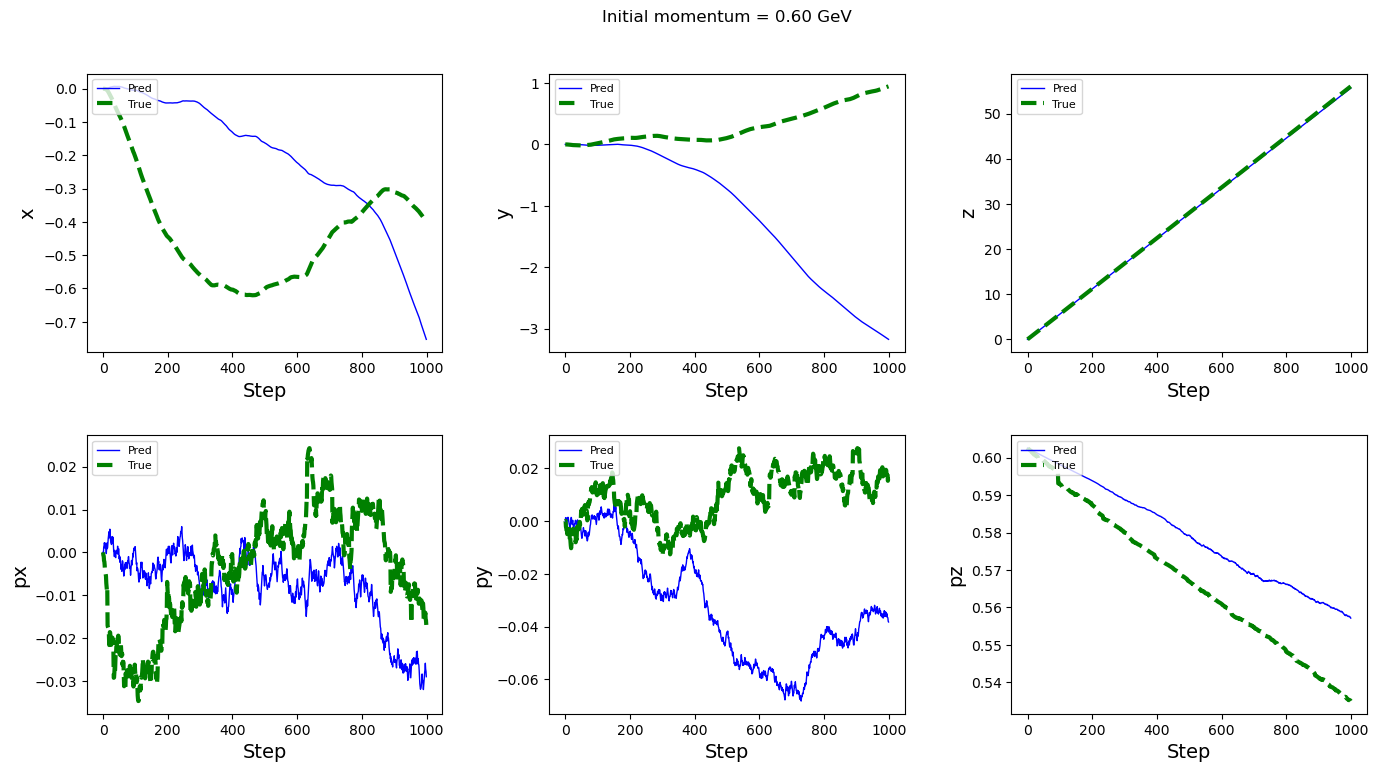

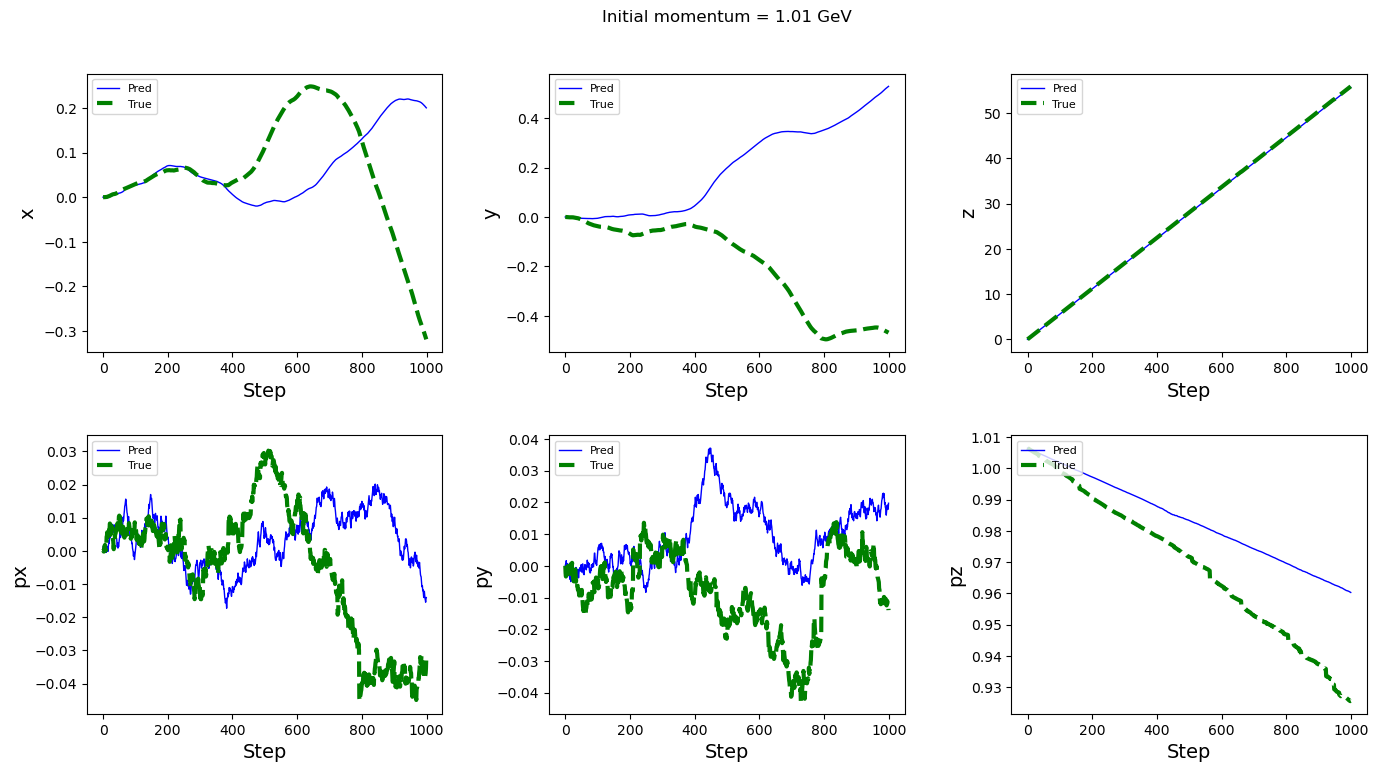

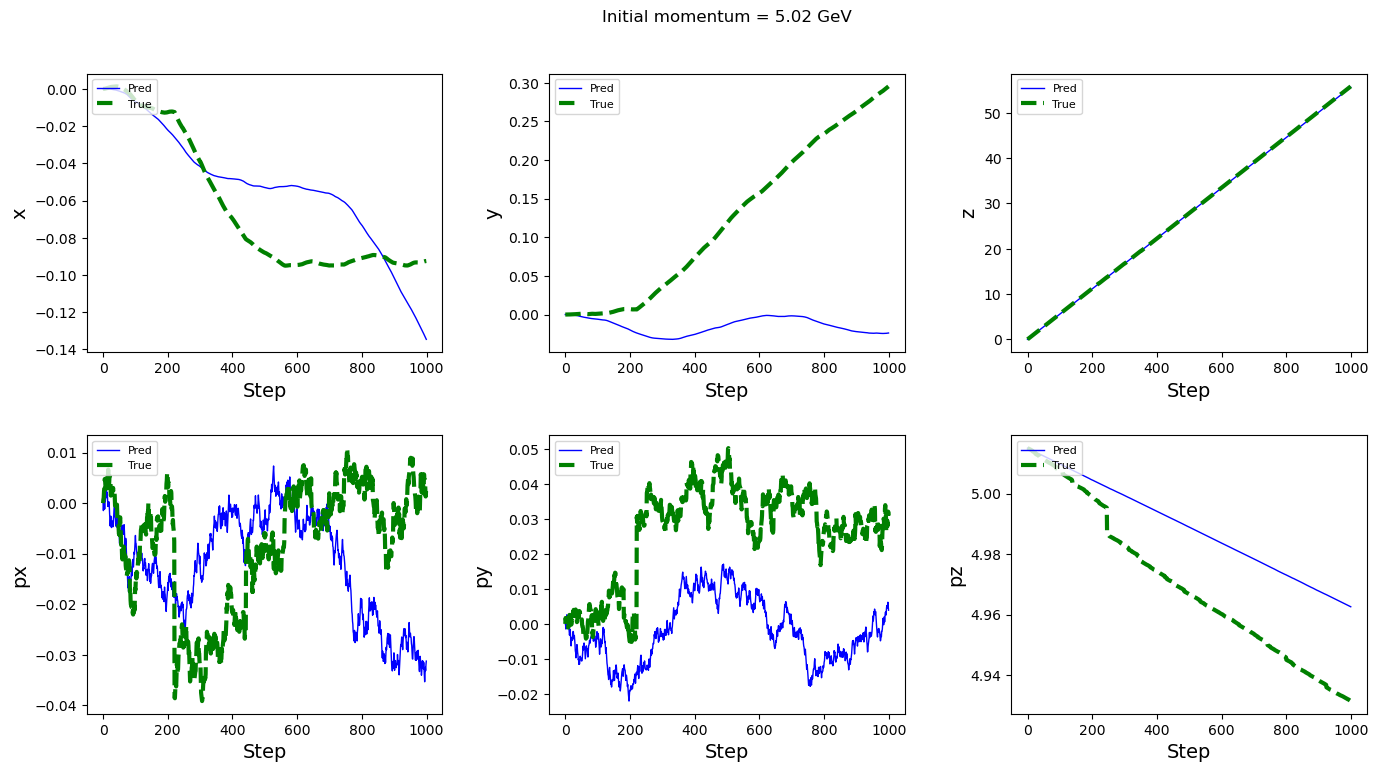

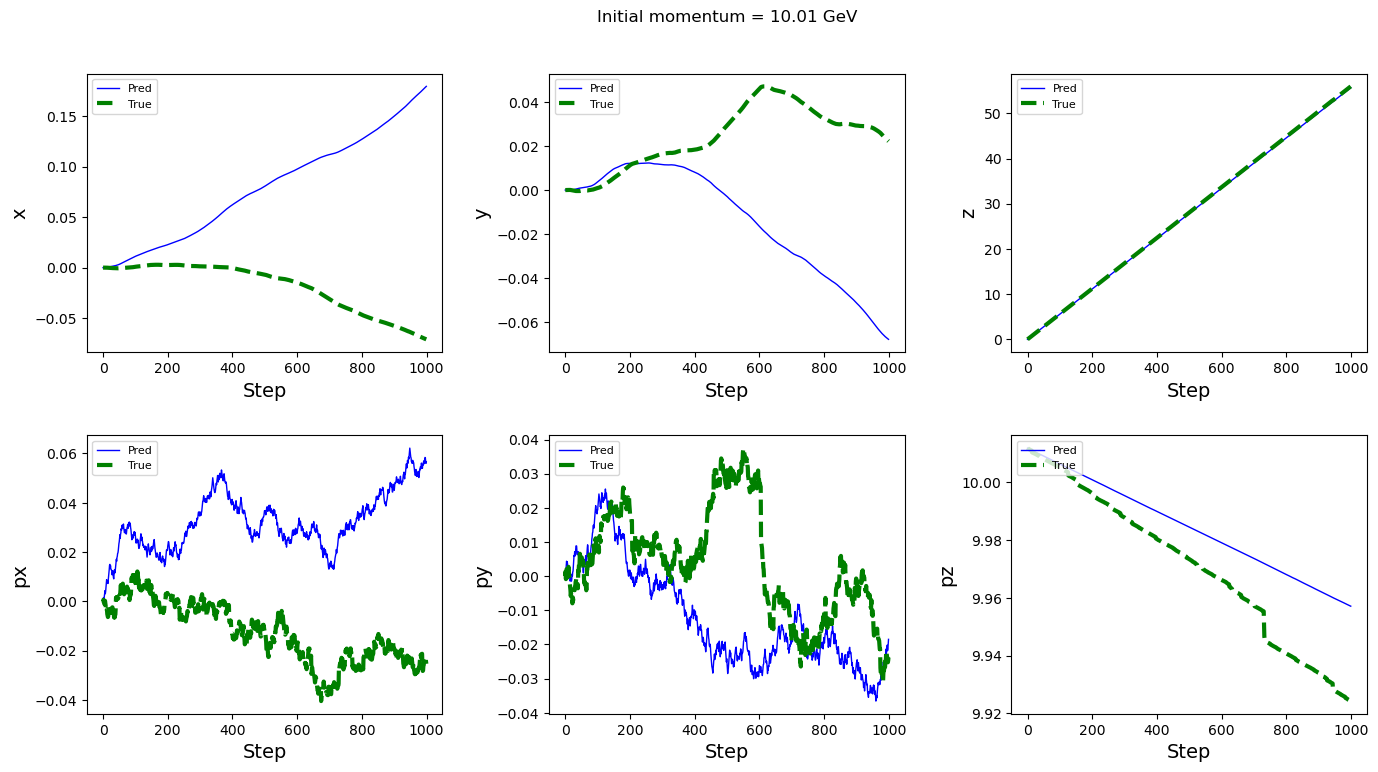

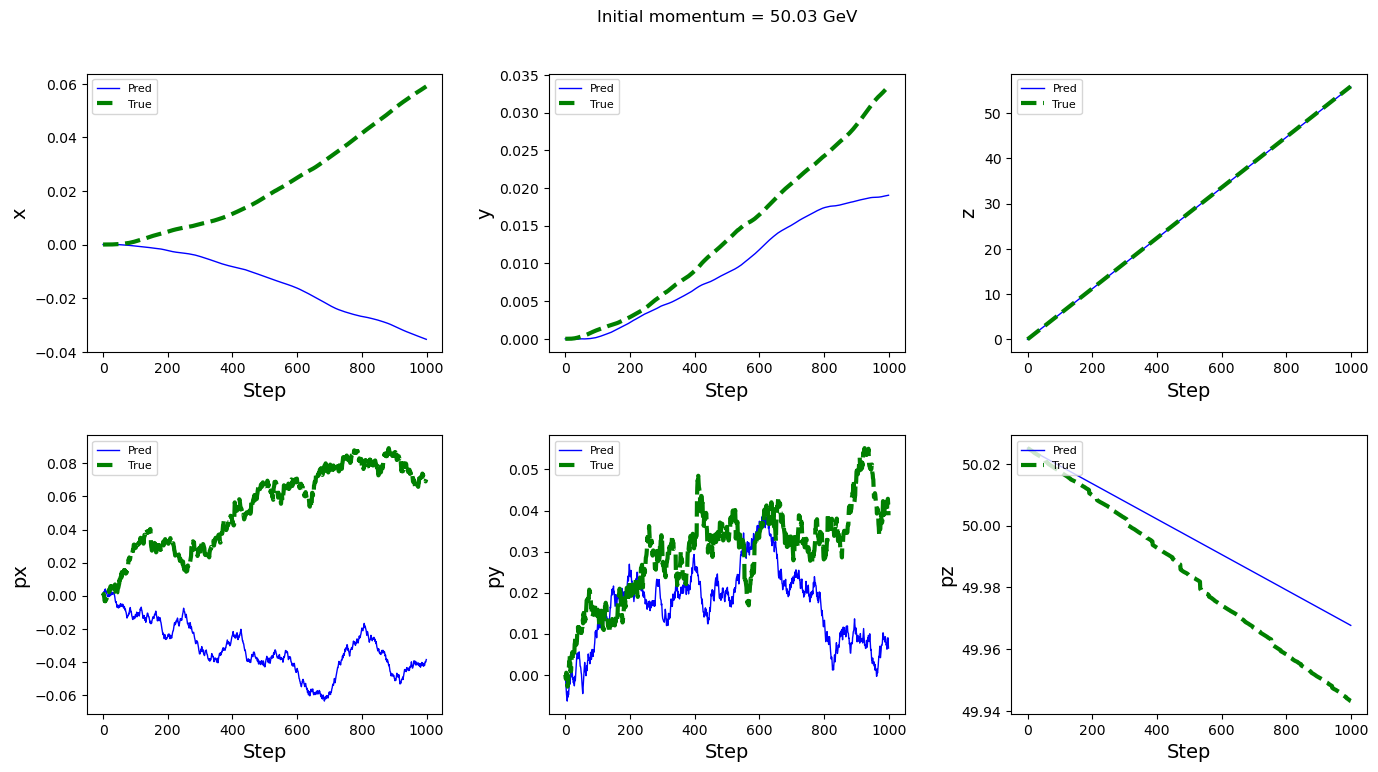

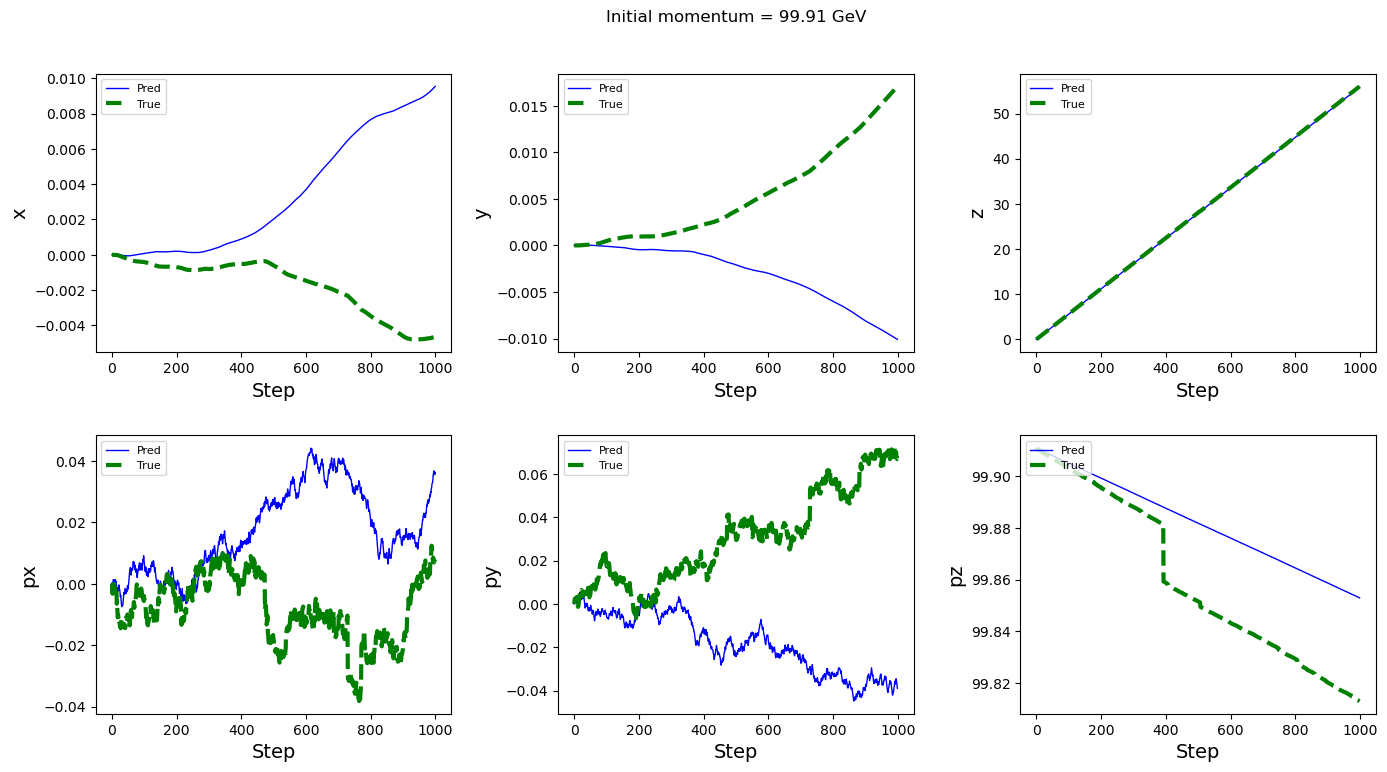

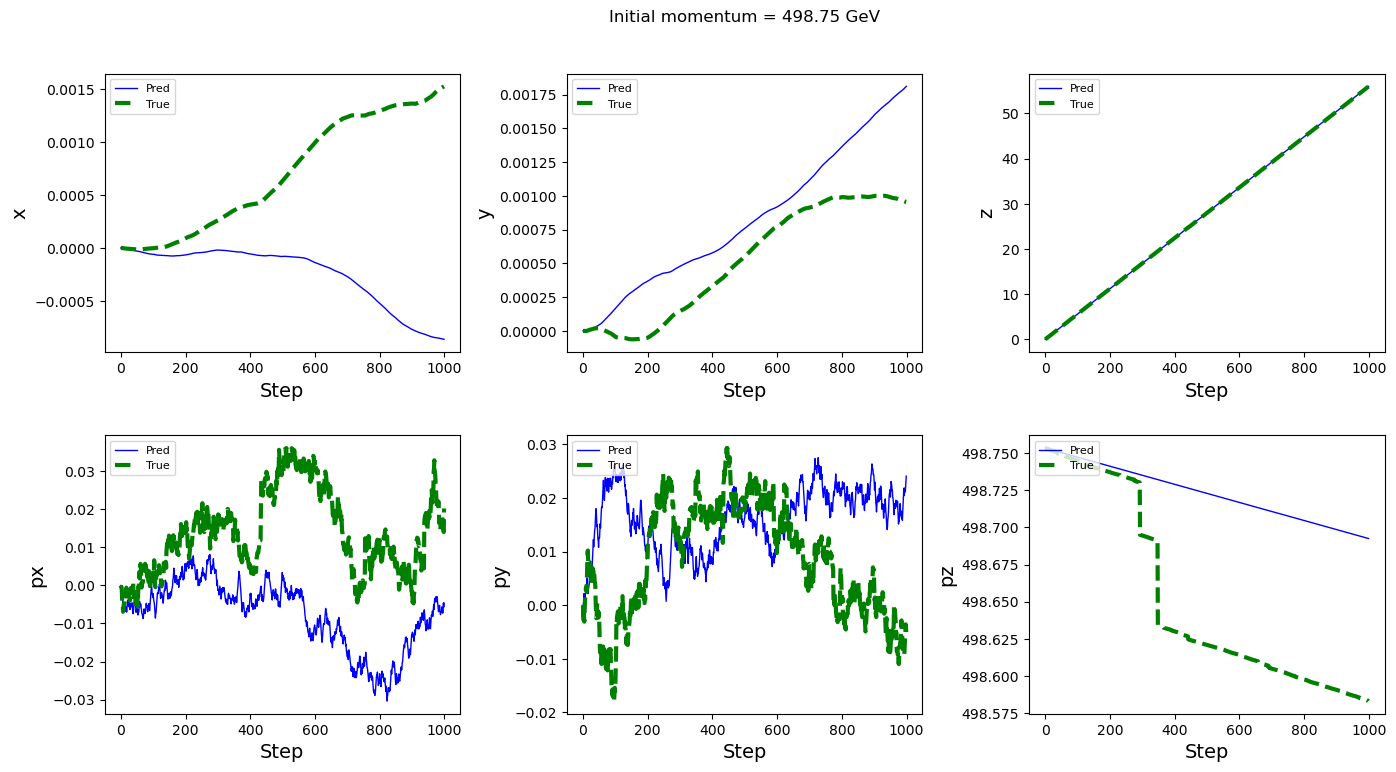

In [42]:
print("\nPlotting Propagation for N_sample = 1...")
figs_prop1 = gan_propagator.plot_sampling(idx=idx, N_sample=1, show=True)


Plotting Propagation for N_sample = 10...


Sampling:   0%|          | 0/10 [00:00<?, ?it/s]

Propagation:   0%|          | 0/999 [00:00<?, ?it/s]

Propagation:   0%|          | 0/999 [00:00<?, ?it/s]

Propagation:   0%|          | 0/999 [00:00<?, ?it/s]

...

Propagation:   0%|          | 0/999 [00:00<?, ?it/s]

Propagation:   0%|          | 0/999 [00:00<?, ?it/s]

Propagation:   0%|          | 0/999 [00:00<?, ?it/s]

Propagation:   0%|          | 0/999 [00:00<?, ?it/s]

Propagation:   0%|          | 0/999 [00:00<?, ?it/s]

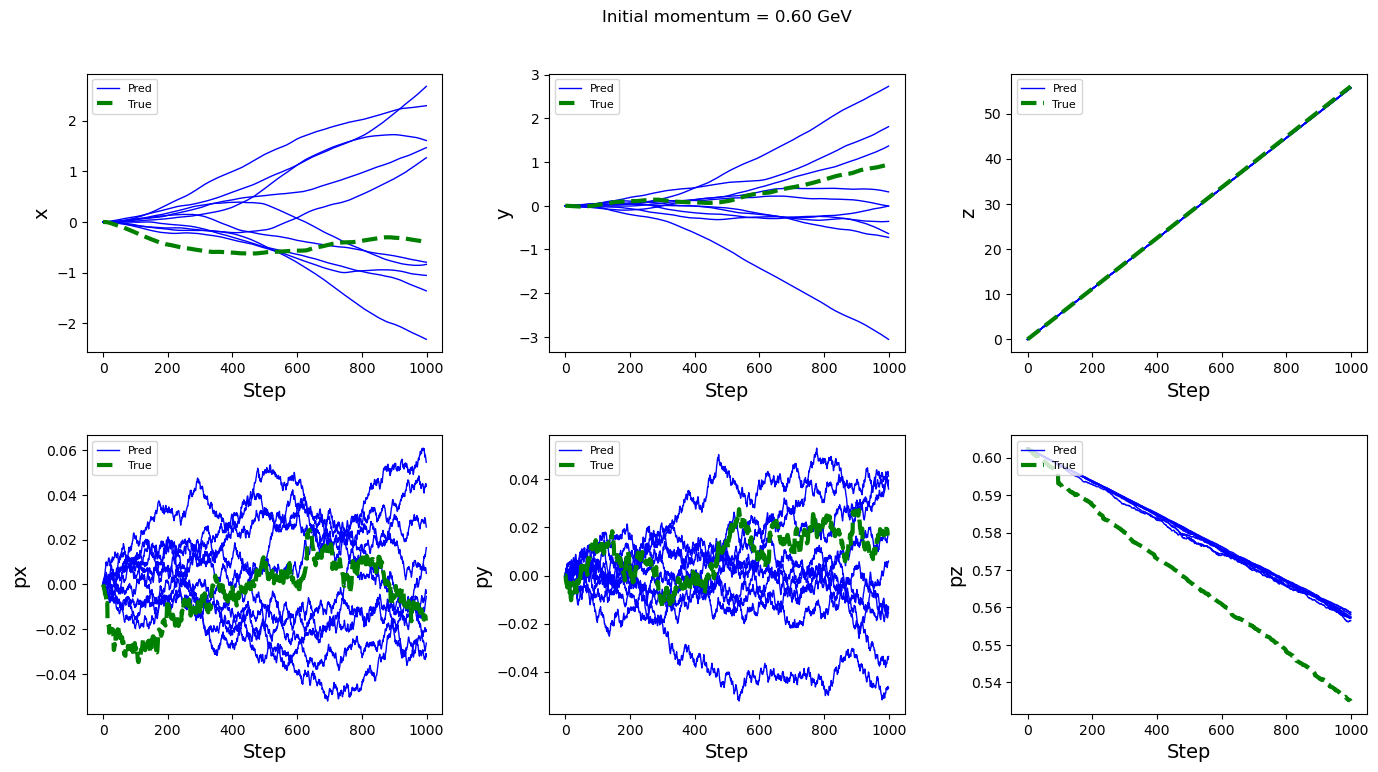

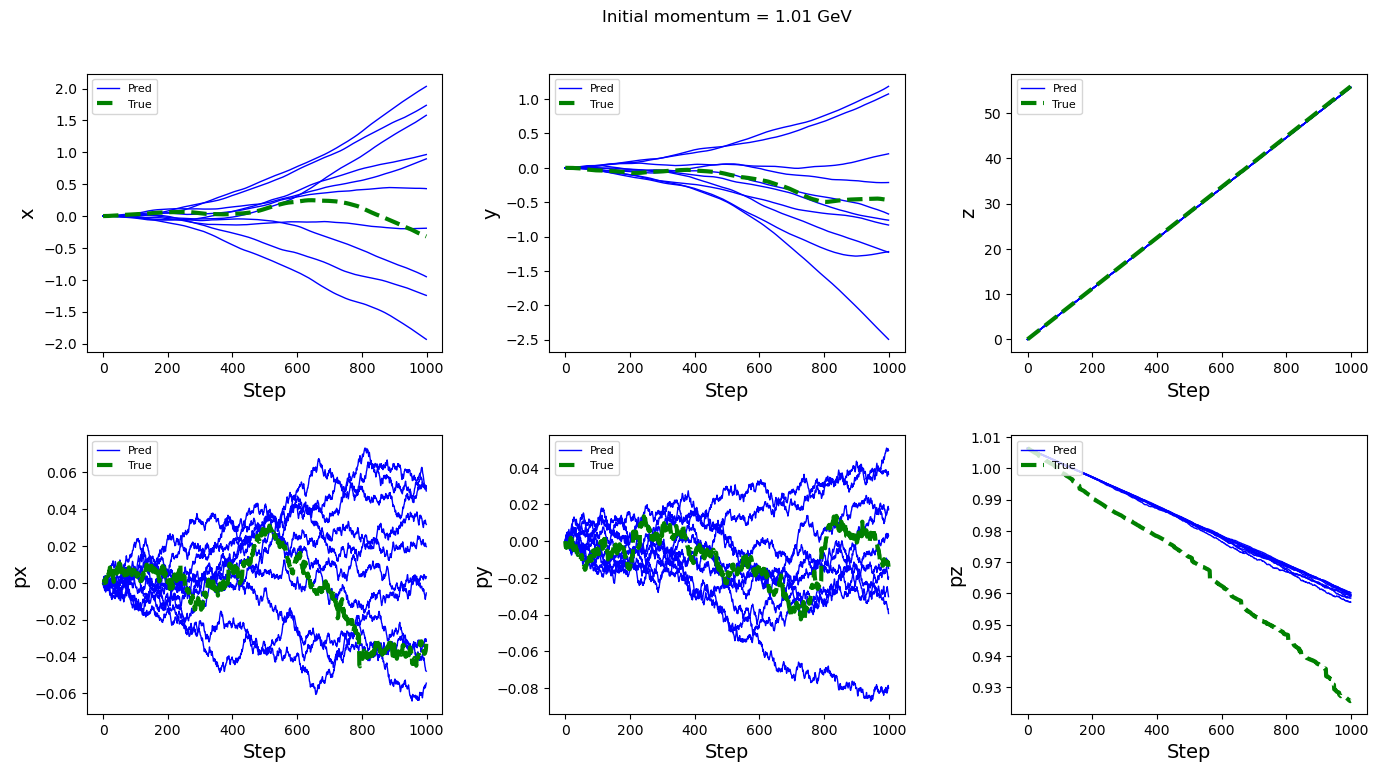

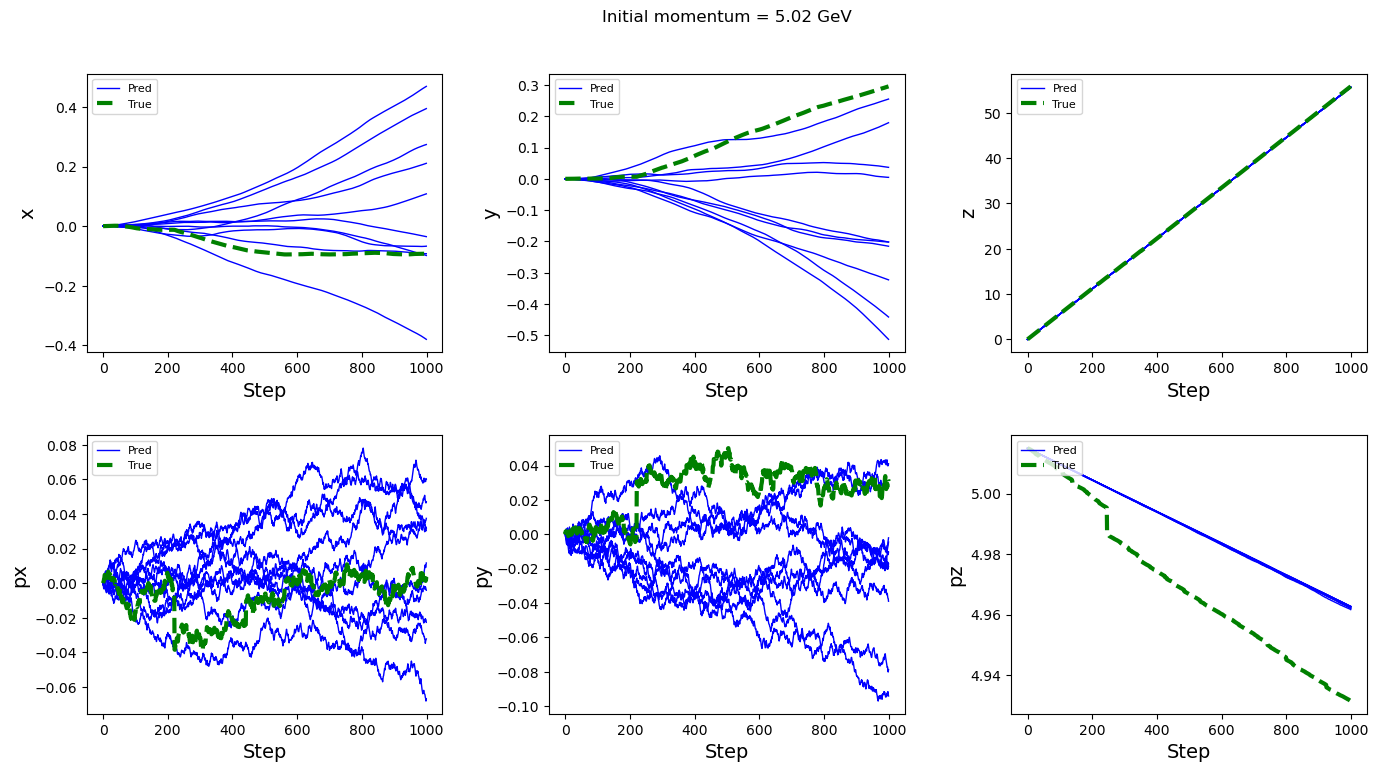

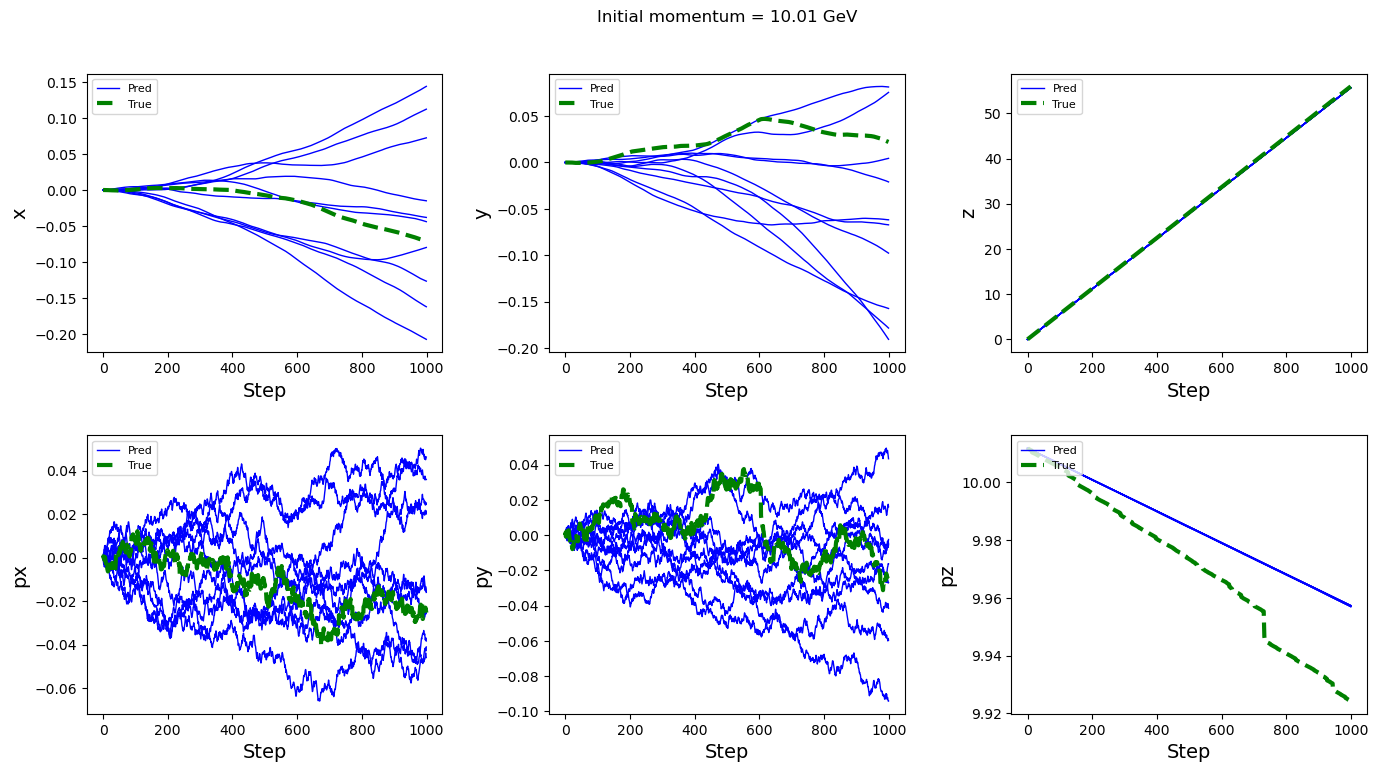

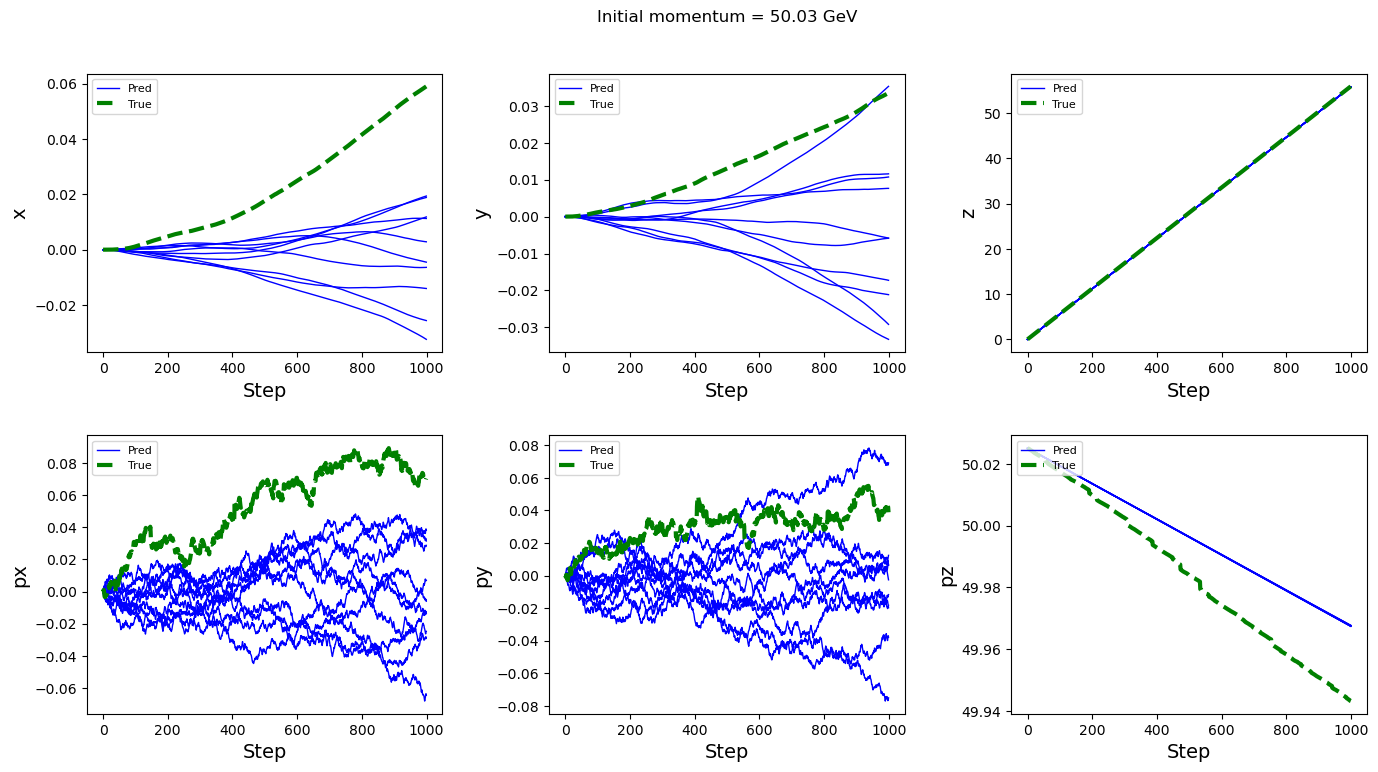

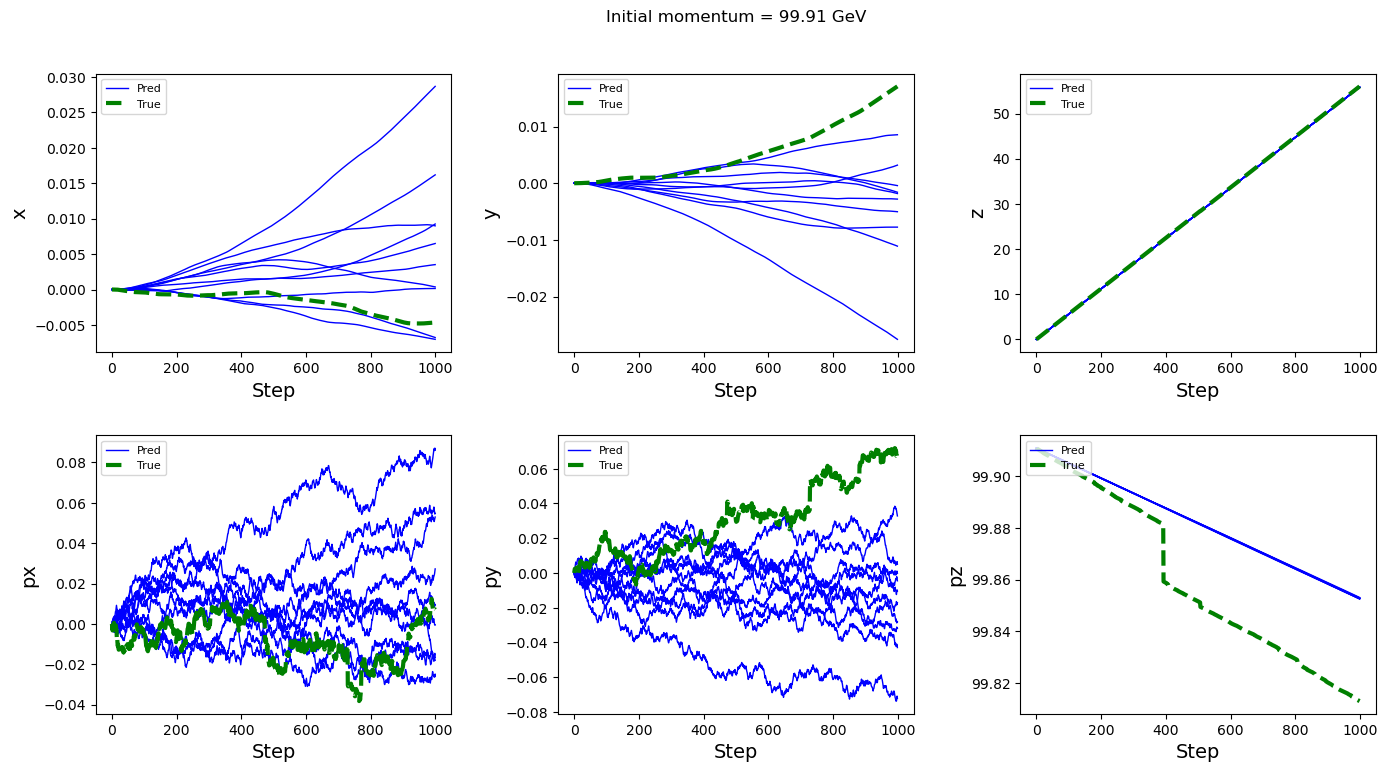

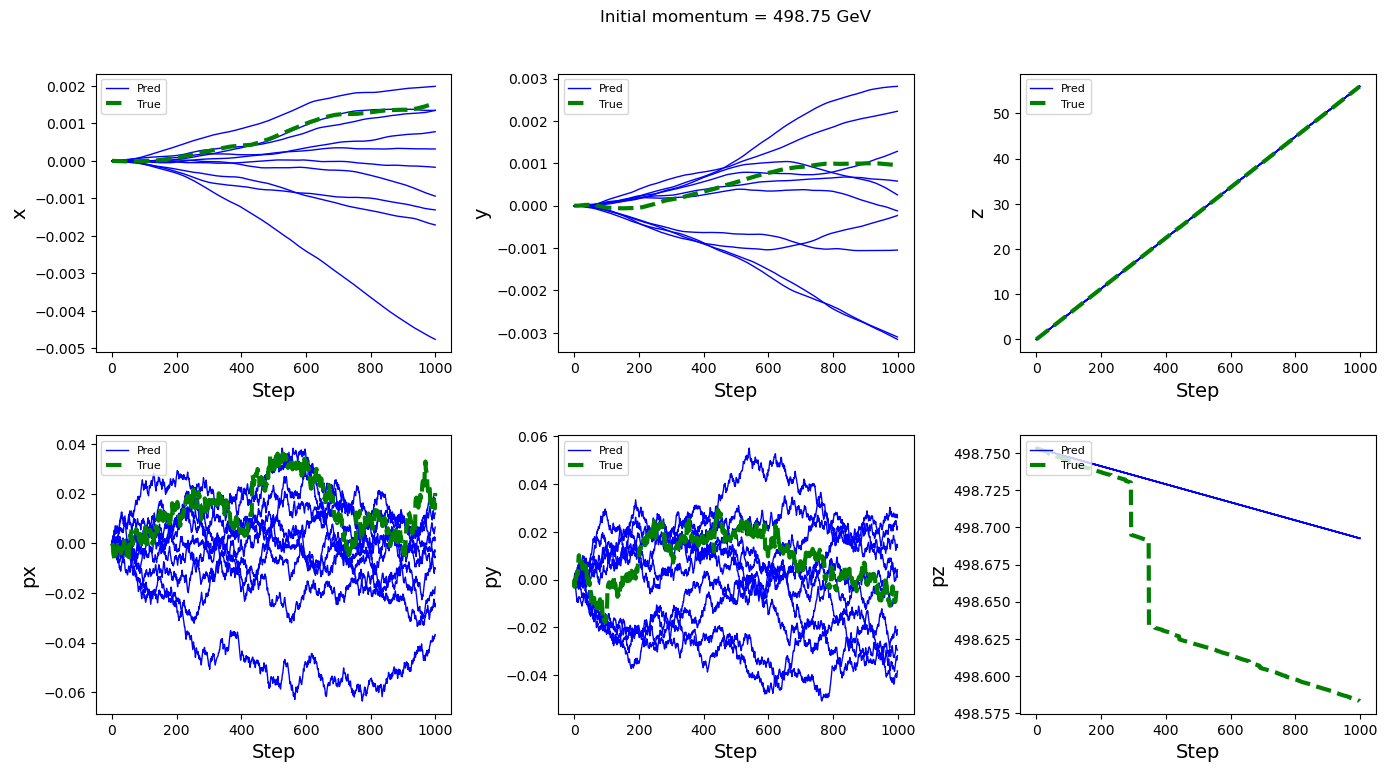

In [43]:
print("\nPlotting Propagation for N_sample = 10...")
figs_prop10 = gan_propagator.plot_sampling(idx=idx, N_sample=10, relative=False, show=True)


Plotting Propagation for N_sample = 100 with quantiles...


Sampling:   0%|          | 0/100 [00:00<?, ?it/s]

Propagation:   0%|          | 0/999 [00:00<?, ?it/s]

Propagation:   0%|          | 0/999 [00:00<?, ?it/s]

Propagation:   0%|          | 0/999 [00:00<?, ?it/s]

...

Propagation:   0%|          | 0/999 [00:00<?, ?it/s]

Propagation:   0%|          | 0/999 [00:00<?, ?it/s]

Propagation:   0%|          | 0/999 [00:00<?, ?it/s]

Propagation:   0%|          | 0/999 [00:00<?, ?it/s]

Propagation:   0%|          | 0/999 [00:00<?, ?it/s]

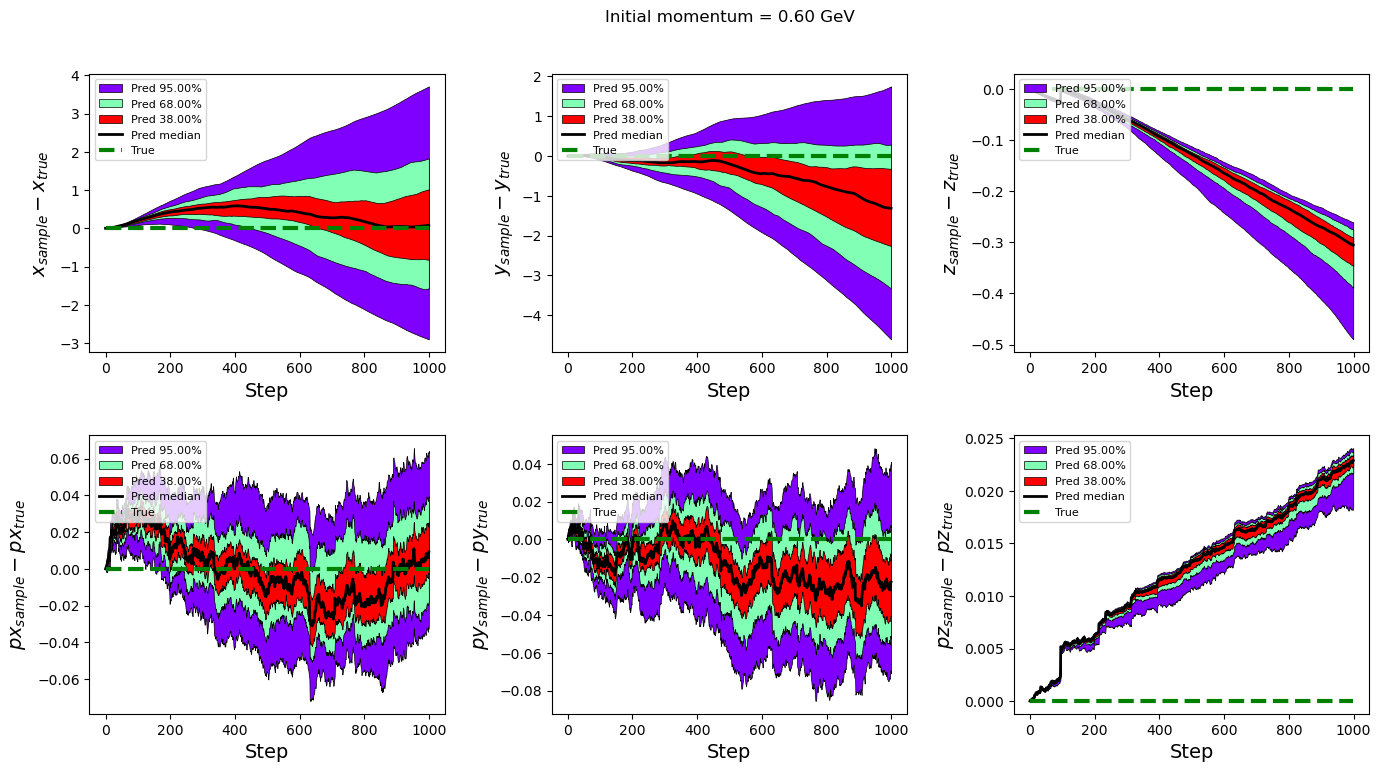

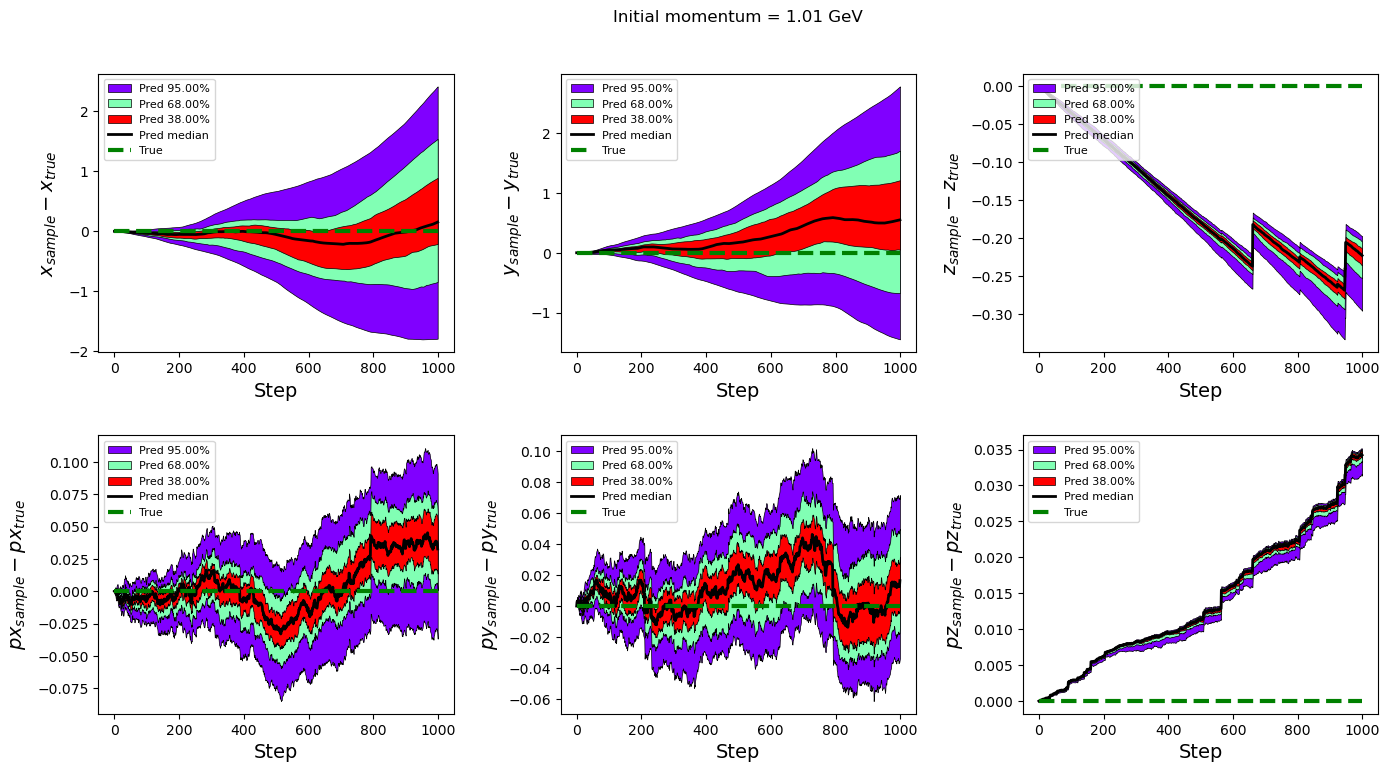

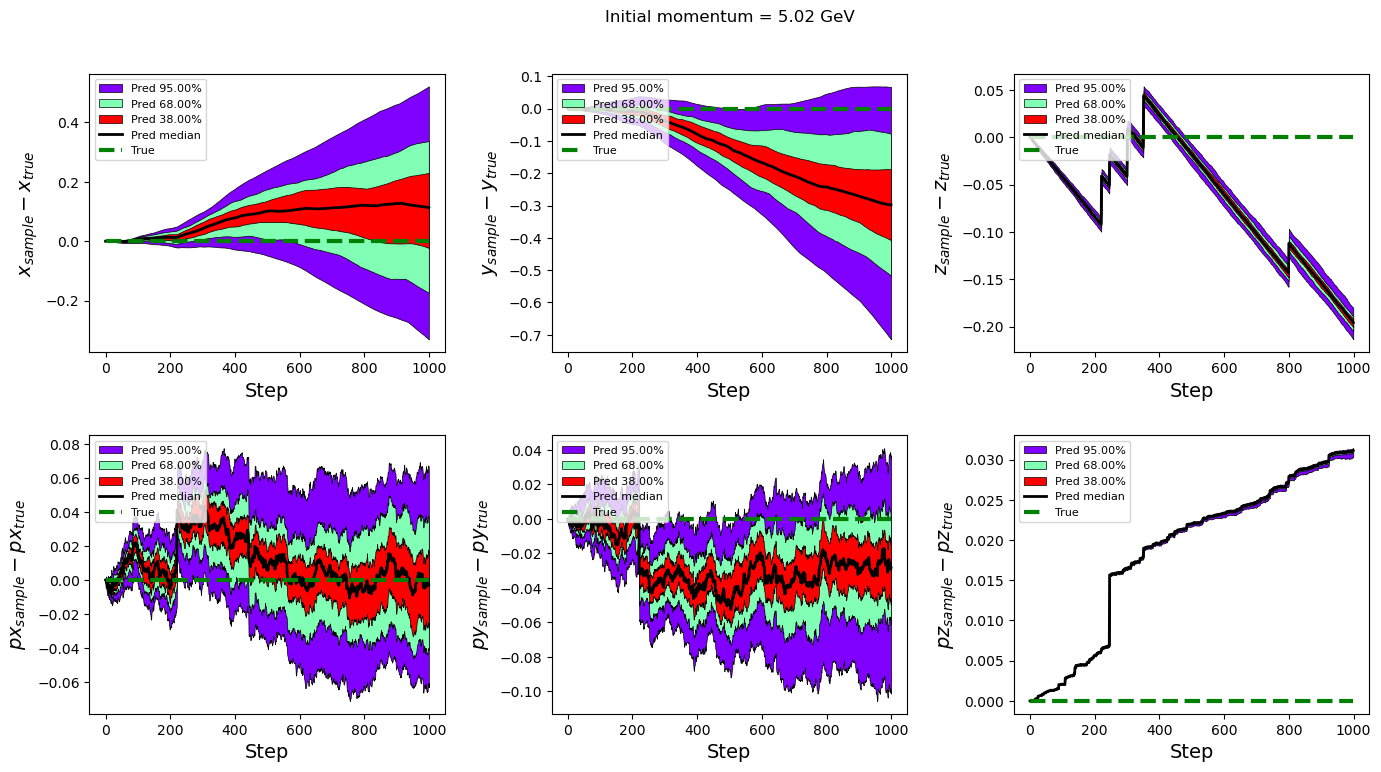

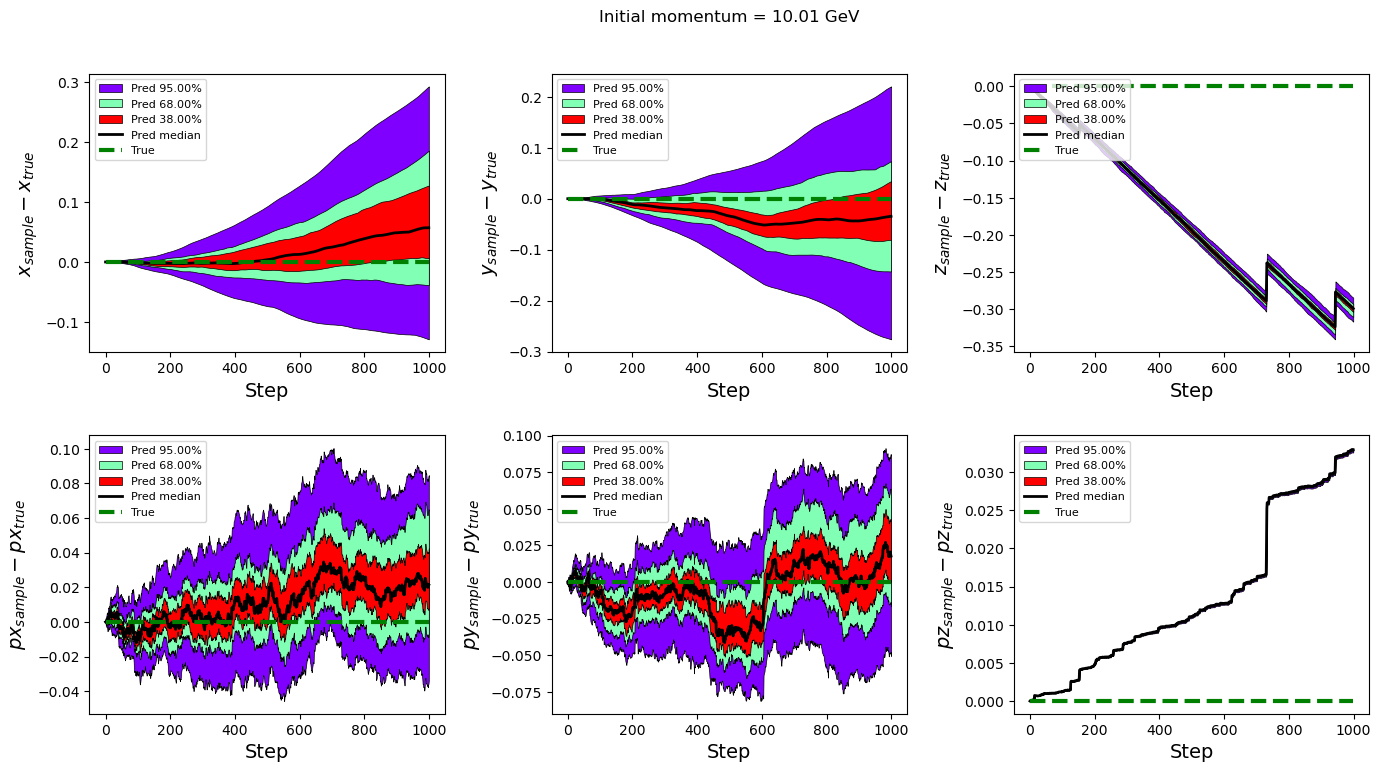

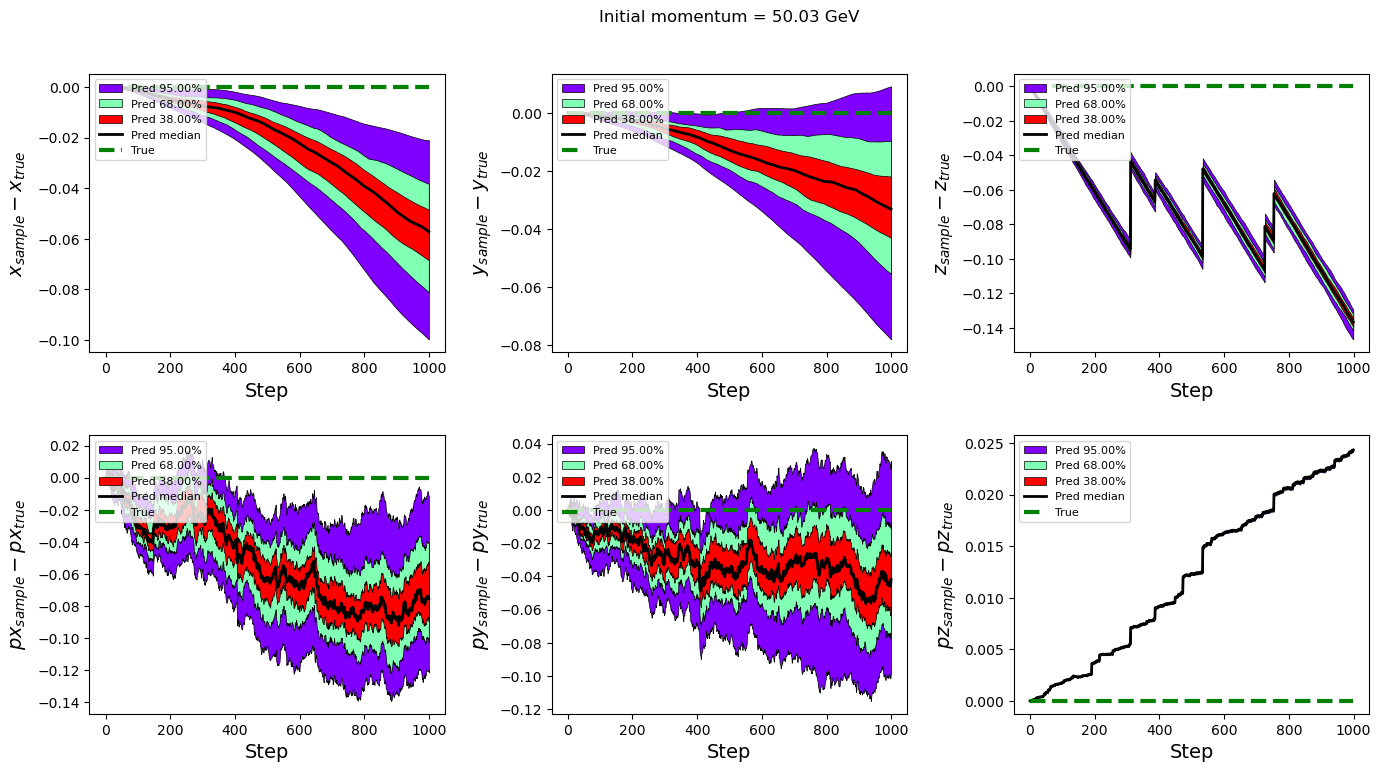

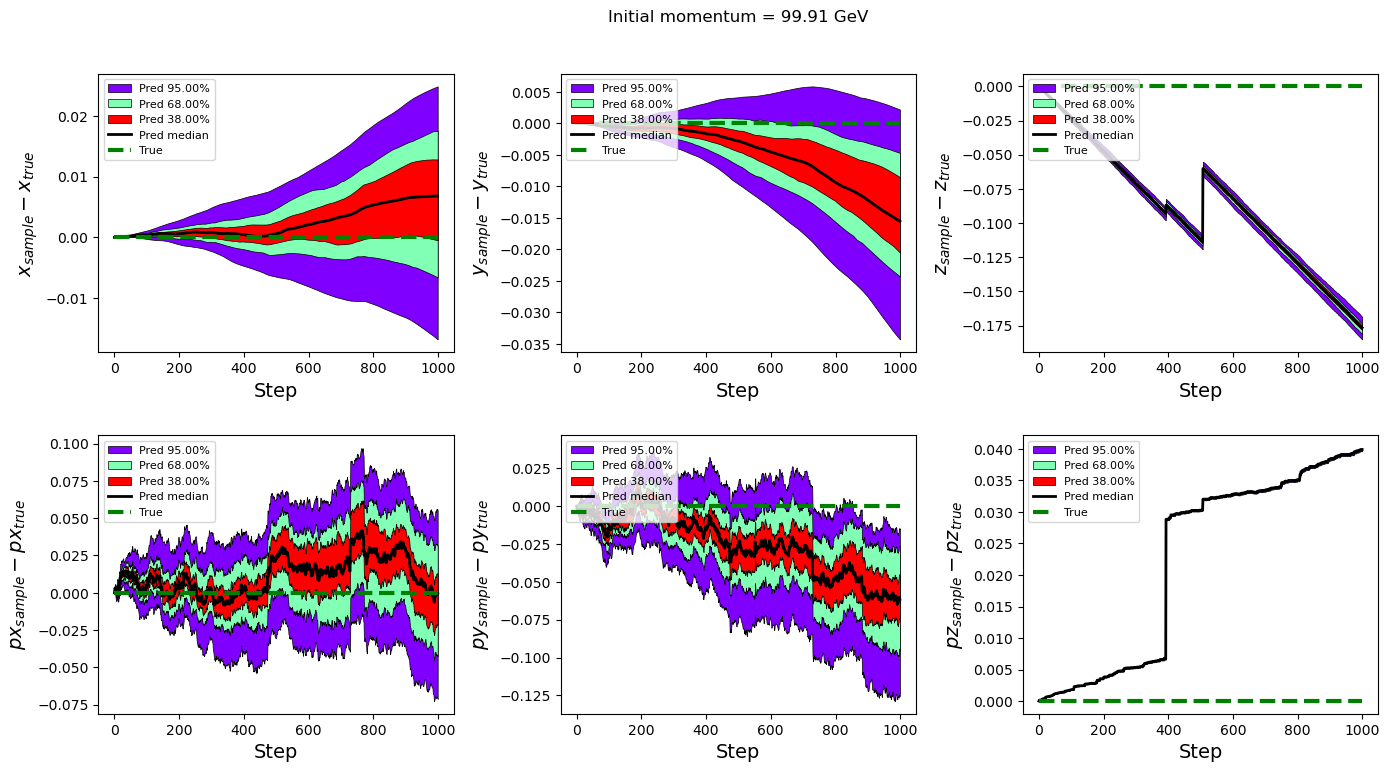

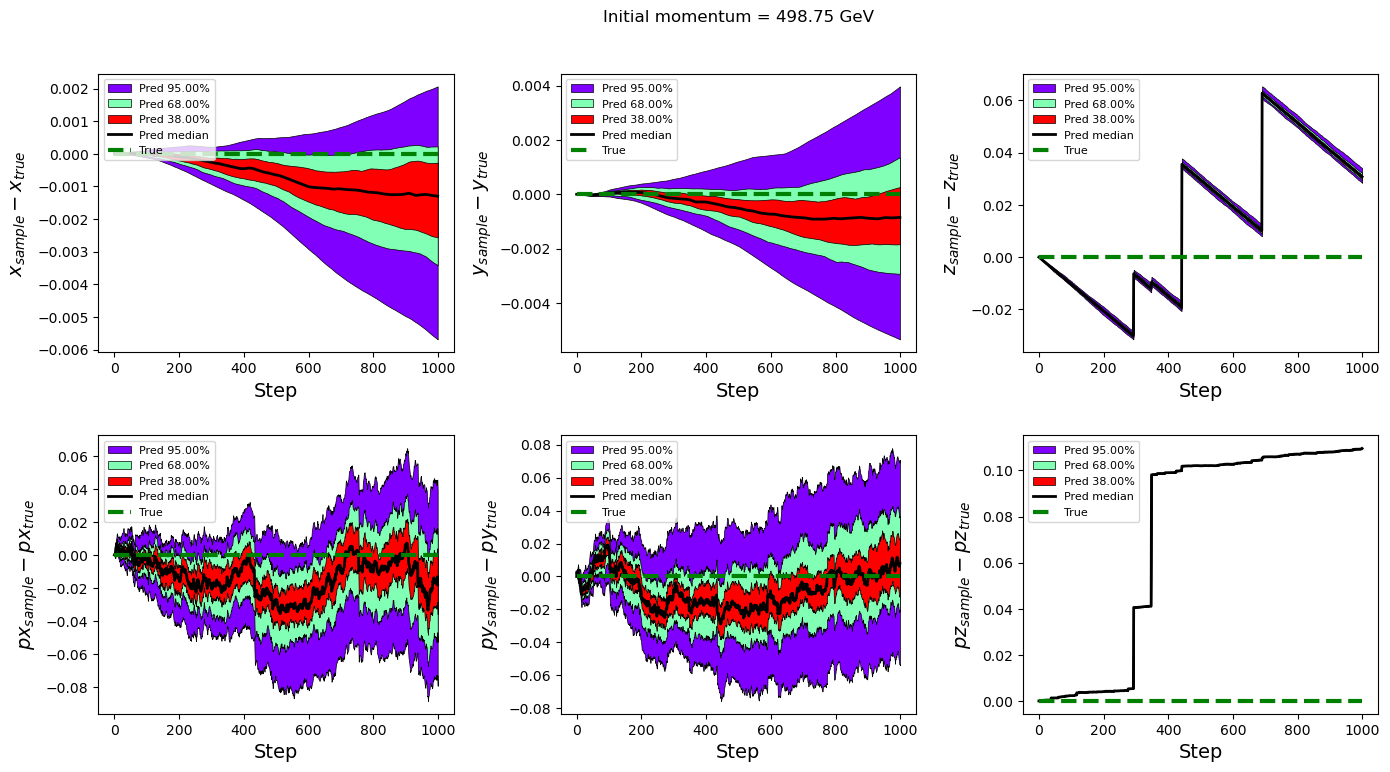

In [44]:
print("\nPlotting Propagation for N_sample = 100 with quantiles...")
figs_prop100 = gan_propagator.plot_sampling(idx=idx, N_sample=100, quantiles=[0.38, 0.68, 0.95], relative=True, show=True)

Batch:   0%|          | 0/1 [00:00<?, ?it/s]

Sampling:   0%|          | 0/100 [00:00<?, ?it/s]

Propagation:   0%|          | 0/999 [00:00<?, ?it/s]

Propagation:   0%|          | 0/999 [00:00<?, ?it/s]

Propagation:   0%|          | 0/999 [00:00<?, ?it/s]

...

Quantiles:   0%|          | 0/21 [00:00<?, ?it/s]

Momentum:   0%|          | 0/3 [00:00<?, ?it/s]

Quantiles:   0%|          | 0/21 [00:00<?, ?it/s]

Quantiles:   0%|          | 0/21 [00:00<?, ?it/s]

Quantiles:   0%|          | 0/21 [00:00<?, ?it/s]

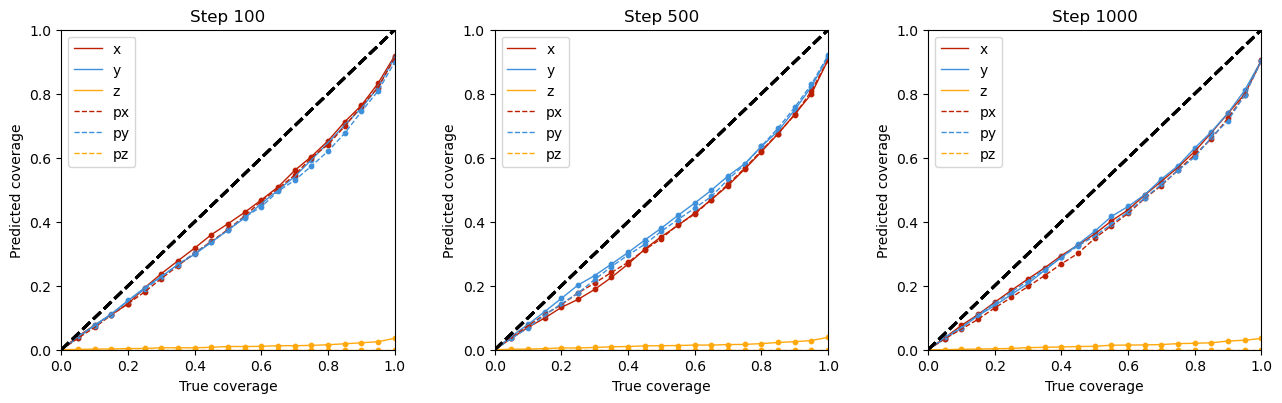

In [45]:
verage = gan_propagator.plot_coverage(N_sample=100,batch_size=10000,steps=[100,500,1000],quantiles=np.r_[0:1:21j])